In [ ]:
('https://console.cloud.google.com/storage/browser/deepmind-gutenberg')

211
Data seems to be loaded already. Skipping download.


In [29]:
!pip install model2vec[distill] sentence-transformers transformers datasets umap-learn plotly

In [19]:
from datasets import load_dataset, load_from_disk
from pathlib import Path
save_dir = Path("data/pg19")
if save_dir.exists():
    ds = load_from_disk(str(save_dir))
else:
    ds = load_dataset("emozilla/pg19")

Loading dataset from disk:   0%|          | 0/23 [00:00<?, ?it/s]

In [5]:
from pathlib import Path
save_dir = Path("data/pg19")
save_dir.mkdir(parents=True, exist_ok=True)
ds.save_to_disk(save_dir)
print(f"Saved dataset to {save_dir.resolve()}")

Saving the dataset (0/23 shards):   0%|          | 0/28602 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/50 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Saved dataset to /home/jovyan/data/pg19


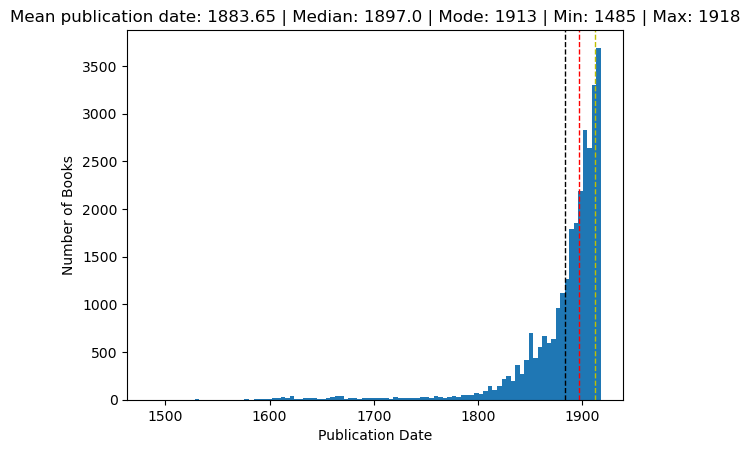

In [21]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist(ds['train']['publication_date'], bins=100)
mu = np.mean(ds['train']['publication_date'])
median = np.median(ds['train']['publication_date'])
mode = np.bincount(ds['train']['publication_date']).argmax()
_min, _max = np.min(ds['train']['publication_date']), np.max(ds['train']['publication_date'])
plt.axvline(mu, color='k', linestyle='dashed', linewidth=1)
plt.axvline(median, color='r', linestyle='dashed', linewidth=1)
plt.axvline(mode, color='y', linestyle='dashed', linewidth=1)
plt.title(f"Mean publication date: {mu:.2f} | Median: {median} | Mode: {mode} | Min: {_min} | Max: {_max}")
plt.xlabel("Publication Date")
plt.ylabel("Number of Books")
plt.show()

In [ ]:
# export corpus from notebook (run where `ds` exists)
from pathlib import Path

fields = ds['train'].column_names
for f in ('text','content','raw_text','body','book_text'):
    if f in fields:
        corpus = "\n\n".join(ds['train'][f])
        break
else:
    raise RuntimeError(f"No text field found in {fields}")

out = Path("data/pg19/corpus.txt")
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(corpus)
print("Wrote", out, "bytes:", out.stat().st_size)

In [32]:
len(ds)

28602

In [35]:
import os
import multiprocessing
from transformers import AutoTokenizer
from datasets import load_from_disk, load_dataset, DatasetDict
from pathlib import Path

# 1. Setup - Use all available CPU cores
num_proc = multiprocessing.cpu_count()
print(f"Using {num_proc} CPU cores for processing.")

# 2. Load Data
save_dir = Path("data/pg19")
if save_dir.exists():
    ds = load_from_disk(str(save_dir))
else:
    ds = load_dataset("emozilla/pg19")

if isinstance(ds, DatasetDict):
    ds = ds['train']

# Select subset (500 books)
ds = ds.select(range(500)) 

# 3. Load Fast Tokenizer
model_id = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

# 4. The "Pack and Slice" Strategy
block_size = 128

def group_texts(examples):
    # a. Tokenize ONLY the text column
    tokenized_inputs = tokenizer(
        examples["text"], 
        return_special_tokens_mask=True,
        truncation=False, 
        add_special_tokens=False
    )
    
    # b. Concatenate all token lists into one huge list
    concatenated_examples = {k: sum(tokenized_inputs[k], []) for k in tokenized_inputs.keys()}
    
    # c. Compute total length safely using 'input_ids'
    total_length = len(concatenated_examples["input_ids"])
    
    # d. Drop remainder
    total_length = (total_length // block_size) * block_size
    
    # e. Split into chunks
    result = {
        k: [t[i : i + block_size] for i in range(0, total_length, block_size)]
        for k, t in concatenated_examples.items()
    }
    
    return result

print("Tokenizing and Packing...")

# IMPORTANT: We explicitly define which columns to remove BEFORE mapping
# so they don't mess up the multiprocessing
cols_to_remove = ds.column_names

lm_dataset = ds.map(
    group_texts,
    batched=True,
    batch_size=100,      # Reduced batch size to safely fit RAM during concat
    num_proc=num_proc,   
    remove_columns=cols_to_remove # Clean out old columns (titles, urls, etc)
)

print(f"Done! Generated {len(lm_dataset)} training samples.")

# 5. Save to Disk
lm_dataset.save_to_disk("data/pg19_processed_tokens")
print("Saved processed dataset to 'data/pg19_processed_tokens'")

Using 108 CPU cores for processing.


Loading dataset from disk:   0%|          | 0/23 [00:00<?, ?it/s]

Tokenizing and Packing...


Map (num_proc=108):   0%|          | 0/500 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (6352 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (24438 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (5482 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (47771 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (50334 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length

Done! Generated 373700 training samples.


Saving the dataset (0/1 shards):   0%|          | 0/373700 [00:00<?, ? examples/s]

Saved processed dataset to 'data/pg19_processed_tokens'


In [104]:
from transformers import AutoModel, AutoTokenizer
import os

# 1. Setup path
model_id = "sentence-transformers/all-MiniLM-L6-v2"
output_path = "models/all-MiniLM-L6-v2"

print(f"Downloading {model_id} in standard Transformers format...")

# 2. Load using AutoModel (NOT SentenceTransformer)
# This strips away the pooling layers and just gets the core Transformer
model = AutoModel.from_pretrained(model_id)
tokenizer = AutoTokenizer.from_pretrained(model_id)

# 3. Save to disk
model.save_pretrained(output_path)
tokenizer.save_pretrained(output_path)

print(f"Success! Model saved to: {output_path}")

Success! Model saved to: models/all-MiniLM-L6-v2


In [48]:
from datasets import load_from_disk
from transformers import AutoModelForMaskedLM, DataCollatorForLanguageModeling, Trainer, TrainingArguments, AutoTokenizer

# 1. Load the pre-processed data
dataset = load_from_disk("data/pg19_processed_tokens")
ds_size = len(dataset)
print(f"Loaded dataset with {ds_size} samples.")
# Shuffle and pick small subset for your GPU
train_dataset = dataset.shuffle(seed=42).select(range(int(ds_size * 0.85)))

# 2. Setup Model
model_id = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForMaskedLM.from_pretrained(model_id)

# 3. Train
args = TrainingArguments(
    output_dir="models/pg19_tuned_teacher",
    per_device_train_batch_size=64, # Higher batch size since data is pre-tokenized
    num_train_epochs=1,
    learning_rate=1e-5,
    fp16=True, # GPU Speedup
    save_strategy="no",
    logging_steps=100
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)
)

trainer.train()
trainer.save_model("models/pg19_tuned_teacher")
tokenizer.save_pretrained("models/pg19_tuned_teacher")

Loaded dataset with 373700 samples.


Some weights of BertForMaskedLM were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
100,7.756500
200,6.783800
300,6.370400
400,6.081200
500,5.882300
600,5.736200
700,5.633100
800,5.537100
900,5.452400
1000,5.352300


('models/pg19_tuned_teacher/tokenizer_config.json',
 'models/pg19_tuned_teacher/special_tokens_map.json',
 'models/pg19_tuned_teacher/vocab.txt',
 'models/pg19_tuned_teacher/added_tokens.json',
 'models/pg19_tuned_teacher/tokenizer.json')

In [69]:
from datasets import load_from_disk
from transformers import (
    AutoModelForMaskedLM, 
    AutoConfig, 
    DataCollatorForLanguageModeling, 
    Trainer, 
    TrainingArguments, 
    AutoTokenizer,
    EarlyStoppingCallback
)

# 1. Load Data & Split
# We need a 'validation' split for early stopping to work.
dataset = load_from_disk("data/pg19_processed_tokens")
ds_size = len(dataset)
print(f"Total samples: {ds_size}")

# Shuffle and split: 90% Train, 10% Validation (Evaluation)
full_split = dataset.shuffle(seed=42).train_test_split(test_size=0.10)
train_dataset = full_split['train']
eval_dataset = full_split['test']

print(f"Training on {len(train_dataset)} samples.")
print(f"Validating on {len(eval_dataset)} samples.")

# 2. Setup Model FROM SCRATCH
model_id = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_id)
config = AutoConfig.from_pretrained(model_id)
model = AutoModelForMaskedLM.from_config(config)

# 3. Training Arguments (Modified for Early Stopping)
args = TrainingArguments(
    output_dir="models/pg19_scratch_teacher",
    per_device_train_batch_size=64, 
    per_device_eval_batch_size=64,  # Batch size for checking validation loss
    
    # Strategy settings
    num_train_epochs=10,         # Set this HIGH (e.g. 10 or 20). Early stopping will cut it short.
    learning_rate=1e-4,
    warmup_steps=500,
    fp16=True, 
    
    # Evaluation & Saving (CRITICAL FOR EARLY STOPPING)
    eval_strategy="steps",       # Check performance every X steps (can also use "epoch")
    eval_steps=200,              # How often to check validation loss
    save_strategy="steps",       # Must match eval_strategy
    save_steps=200,              # Save checkpoint every time we eval
    
    # Early Stopping Config
    load_best_model_at_end=True, # When stopping, revert to the best checkpoint, not the last one
    metric_for_best_model="loss",# Watch the Validation Loss
    greater_is_better=False,     # Lower loss is better
    save_total_limit=2,          # Delete old checkpoints to save disk space
    logging_steps=50,
)

# 4. Initialize Trainer with Callback
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,   # Pass the validation data here
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15),
    
    # Add the "Stopper"
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] 
    # Patience=3 means: "If loss doesn't improve for 3 evaluations in a row, STOP."
)

print("Starting pre-training with Early Stopping...")
trainer.train()

# 5. Save the BEST model (Trainer automatically loaded it)
trainer.save_model("models/pg19_scratch_teacher_best")
tokenizer.save_pretrained("models/pg19_scratch_teacher_best")
print("Training finished. Best model saved.")

Total samples: 373700
Training on 336330 samples.
Validating on 37370 samples.
Starting pre-training with Early Stopping...


Step,Training Loss,Validation Loss
200,8.418700,8.040678
400,6.687600,6.638578
600,6.468000,6.418091
800,6.339300,6.301286
1000,6.259500,6.238420
1200,6.227000,6.185666
1400,6.173600,6.136358
1600,6.164400,6.116295
1800,6.087000,6.088723
2000,6.074500,6.053277


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

There were missing keys in the checkpoint model loaded: ['cls.predictions.decoder.weight', 'cls.predictions.decoder.bias'].


Training finished. Best model saved.


In [95]:
from datasets import load_from_disk
from transformers import (
    AutoModelForMaskedLM, 
    DataCollatorForLanguageModeling, 
    Trainer, 
    TrainingArguments, 
    AutoTokenizer
)

# 1. Load Data
dataset = load_from_disk("data/pg19_processed_tokens")
# Use a larger slice if your GPU allows (e.g. 80k)
train_dataset = dataset.shuffle(seed=42).select(range(int(ds_size * 1.00)))

# 2. Setup Model (PRE-TRAINED, not Scratch)
model_id = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForMaskedLM.from_pretrained(model_id)

# 3. Aggressive Arguments
args = TrainingArguments(
    output_dir="models/pg19_aggressive_tuning",
    per_device_train_batch_size=64,
    num_train_epochs=3,           # High epochs to overwrite modern bias
    learning_rate=6e-5,           # Aggressive learning rate (standard is 2e-5)
    fp16=True,
    save_strategy="no",
    logging_steps=400
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)
)

print("Starting Aggressive Domain Adaptation...")
trainer.train()

trainer.save_model("models/pg19_aggressive_tuning")
tokenizer.save_pretrained("models/pg19_aggressive_tuning")

Some weights of BertForMaskedLM were not initialized from the model checkpoint at sentence-transformers/all-MiniLM-L6-v2 and are newly initialized: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting Aggressive Domain Adaptation...


Step,Training Loss
400,5.570600
800,4.633000
1200,4.374700
1600,4.225800
2000,4.120700
2400,4.041400
2800,3.972800
3200,3.919500
3600,3.880300
4000,3.833500


('models/pg19_aggressive_tuning/tokenizer_config.json',
 'models/pg19_aggressive_tuning/special_tokens_map.json',
 'models/pg19_aggressive_tuning/vocab.txt',
 'models/pg19_aggressive_tuning/added_tokens.json',
 'models/pg19_aggressive_tuning/tokenizer.json')

In [109]:
from model2vec.distill import distill
import torch

# 1. Define paths
teacher_path = "models/pg19_tuned_teacher"  # The model you just trained
teacher_path = "models/pg19_scratch_teacher_best"  # The model you just trained
teacher_path = "models/pg19_aggressive_tuning"  # The model you just trained
teacher_path = "models/all-MiniLM-L6-v2"  # The model you just trained
save_path = "models/pg19_static_final"      # Where the static vectors will live
save_path = "models/pg19_scratch_static_final"      # Where the static vectors will live
save_path = "models/pg19_aggressive_static_final"      # Where the static vectors will live
save_path = "models/all-MiniLM-L6-v2_static"      # Where the static vectors will live

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Distilling from {teacher_path} on {device}...")

# 2. Distill
# This asks your new teacher: "What is the single best vector for 'broadcast'?"
pg19_static = distill(
    model_name=teacher_path,
    device=device
)

# 3. Save the Static Model
pg19_static.save_pretrained(save_path)
print(f"Distillation complete! Static model saved to: {save_path}")

Distilling from models/all-MiniLM-L6-v2 on cuda...


Encoding tokens: 100%|██████████| 29524/29524 [00:00<00:00, 33800.84 tokens/s]


Distillation complete! Static model saved to: models/all-MiniLM-L6-v2_static


In [110]:
from model2vec import StaticModel
from scipy.spatial.distance import cosine

# Load both models
model_modern = StaticModel.from_pretrained("minishlab/potion-base-8m") # Modern Baseline
model_pg19 = StaticModel.from_pretrained("models/pg19_static_final")   # Your 19th Century Model (fine-tuned)
model_pg19 = StaticModel.from_pretrained("models/pg19_scratch_static_final")   # pre-trained from scratch
model_pg19 = StaticModel.from_pretrained("models/pg19_aggressive_static_final")   # pre-trained from scratch
model_pg19 = StaticModel.from_pretrained("models/all-MiniLM-L6-v2_static")   # pre-trained from scratch

# Define the Probe
word = "broadcast"
anchor = "farm"

# 1. Modern Distance
vec_mod_word = model_modern.encode([word])[0]
vec_mod_anchor = model_modern.encode([anchor])[0]
dist_mod = cosine(vec_mod_word, vec_mod_anchor)

# 2. PG-19 Distance
vec_old_word = model_pg19.encode([word])[0]
vec_old_anchor = model_pg19.encode([anchor])[0]
dist_old = cosine(vec_old_word, vec_old_anchor)

print(f"Distance '{word}' <-> '{anchor}'")
print(f"Modern Model: {dist_mod:.4f} (Should be far, > 0.6)")
print(f"PG-19 Model:  {dist_old:.4f} (Should be closer, < 0.5)")

diff = dist_mod - dist_old
if diff > 0:
    print(f"\nSUCCESS: The word moved {diff:.4f} closer to farming!")
else:
    print("\nWARNING: No significant drift detected. You might need to train for more epochs.")

Distance 'broadcast' <-> 'farm'
Modern Model: 0.9612 (Should be far, > 0.6)
PG-19 Model:  0.9312 (Should be closer, < 0.5)

SUCCESS: The word moved 0.0300 closer to farming!


In [111]:
def sanity_check(model, name):
    print(f"--- Sanity Check: {name} ---")
    # 1. Check Synonyms (Should be close, Dist < 0.5)
    d1 = cosine(model.encode(["good"])[0], model.encode(["great"])[0])
    print(f"Distance 'good' <-> 'great': {d1:.4f} {'✅' if d1 < 0.6 else '❌ BROKEN'}")

    # 2. Check Unrelated (Should be far, Dist ~ 1.0)
    d2 = cosine(model.encode(["apple"])[0], model.encode(["car"])[0])
    print(f"Distance 'apple' <-> 'car':   {d2:.4f} {'✅' if d2 > 0.7 else '❌ BROKEN'}")
    print("")

# Run on your scratch model
sanity_check(model_pg19, "PG-19 From Scratch")

--- Sanity Check: PG-19 From Scratch ---
Distance 'good' <-> 'great': 0.2363 ✅
Distance 'apple' <-> 'car':   0.7537 ✅



Loading models...
Common vocabulary size: 27007
Alignment rotation calculated.
Calculating drift scores...

Top Drifting Words detected:
olved: 1.3157
zquez: 1.2549
phobia: 1.2269
ops: 1.2253
peed: 1.2155
[UNK]: 1.1985
[PAD]: 1.1973
uber: 1.1969
ogenic: 1.1864
▁2a: 1.1818
thic: 1.1741
phic: 1.1692
▁1a: 1.1664
▁2014: 1.1653
onzo: 1.1638


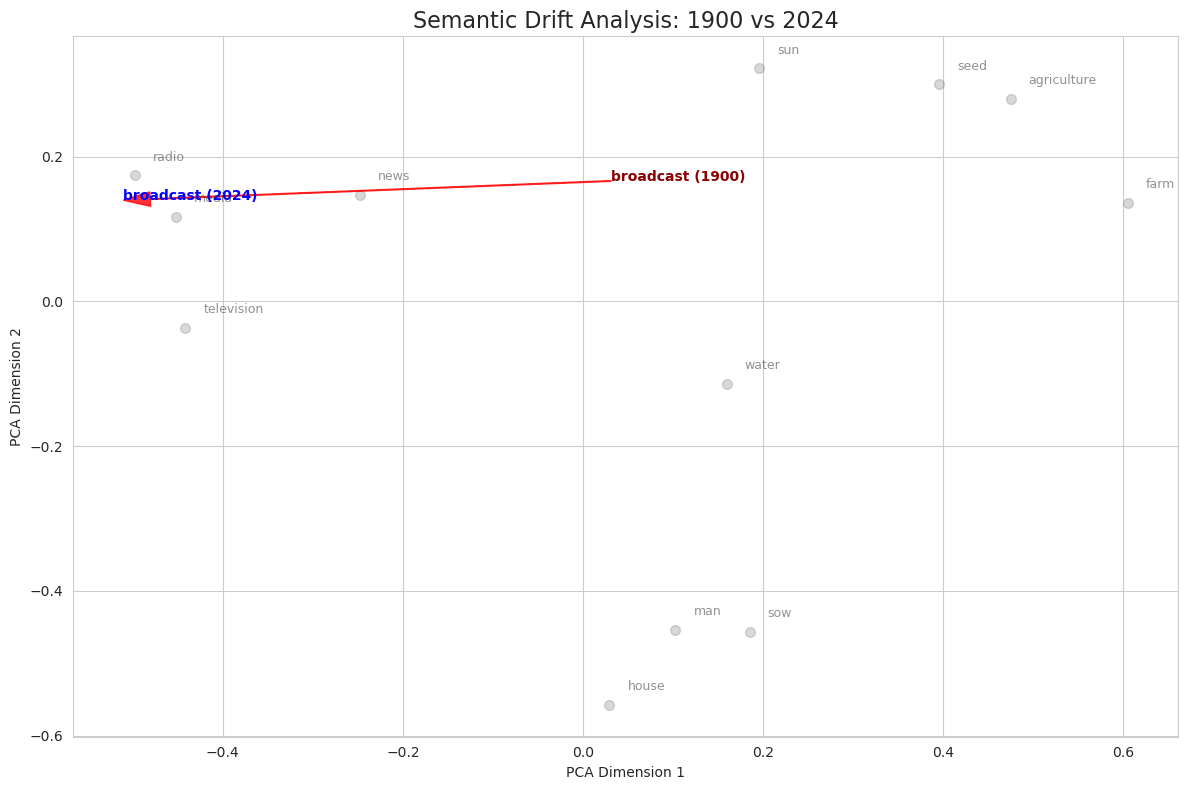

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
from model2vec import StaticModel
from scipy.spatial.distance import cosine

# --- CONFIGURATION ---
MODERN_PATH = "minishlab/potion-base-8m" # Or your distilled modern base
MODERN_PATH = "models/all-MiniLM-L6-v2_static" # Or your distilled modern base
PG19_PATH = "models/pg19_static_final"   # Your trained model
PG19_PATH = "models/pg19_scratch_static_final"   # Your trained model
PG19_PATH = "models/pg19_aggressive_static_final"   # Your trained model

# Words to ignore (stopwords/punctuation) for drift calculation
IGNORE_LIST = set(["the", "of", "and", "to", "a", "in", "is", "it", "that", "i", "unused"])

def load_and_align_models():
    print("Loading models...")
    # Load models
    mod_modern = StaticModel.from_pretrained(MODERN_PATH)
    mod_pg19 = StaticModel.from_pretrained(PG19_PATH)
    
    # --- FIX START ---
    # Use .get_vocab() instead of .vocab
    vocab_modern = set(mod_modern.tokenizer.get_vocab().keys())
    vocab_pg19 = set(mod_pg19.tokenizer.get_vocab().keys())
    # --- FIX END ---
    
    common_vocab = sorted(list(vocab_modern.intersection(vocab_pg19)))
    
    # Filter common vocab (remove unused tokens)
    common_vocab = [w for w in common_vocab if w not in IGNORE_LIST and len(w) > 2]
    
    print(f"Common vocabulary size: {len(common_vocab)}")
    
    # 2. Create Matrix of Vectors for Common Words
    # We use stable words (top 2000 common freq words usually) as anchors
    anchors = common_vocab[:2000] 
    
    A = mod_modern.encode(anchors)
    B = mod_pg19.encode(anchors)
    
    # 3. Calculate Optimal Rotation (Procrustes Analysis)
    # This finds matrix R that minimizes ||A - BR||
    R, _ = orthogonal_procrustes(B, A)
    
    print("Alignment rotation calculated.")
    
    return mod_modern, mod_pg19, R, common_vocab

def get_top_drifters(mod_modern, mod_pg19, R, vocab, top_k=15):
    drifts = []
    
    # Check drifts for potentially interesting words
    # (Scanning all 100k words takes time, scanning first 5k is usually enough for demo)
    scan_vocab = vocab[:5000] 
    
    vecs_modern = mod_modern.encode(scan_vocab)
    vecs_pg19_raw = mod_pg19.encode(scan_vocab)
    
    # Apply alignment to PG19
    vecs_pg19_aligned = vecs_pg19_raw @ R
    
    print("Calculating drift scores...")
    for i, word in enumerate(scan_vocab):
        # Cosine distance (1 - similarity)
        # We assume vectors are normalized, but let's be safe
        v1 = vecs_modern[i]
        v2 = vecs_pg19_aligned[i]
        dist = 1 - (np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))
        drifts.append((word, dist))
        
    # Sort by highest drift
    drifts.sort(key=lambda x: x[1], reverse=True)
    return drifts[:top_k]

def plot_semantic_trajectory(mod_modern, mod_pg19, R, target_words, context_anchors):
    """
    Plots the movement of 'target_words' against a background of 'context_anchors'
    """
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    
    # 1. Gather all words to define the 2D space
    all_words = list(target_words) + context_anchors
    
    # We define the "Map" using the MODERN meaning locations
    # So we know where "Farm" and "Radio" live in the modern mind.
    base_vectors = mod_modern.encode(all_words)
    
    # Reduce to 2D
    pca = PCA(n_components=2)
    coords_base = pca.fit_transform(base_vectors)
    
    # 2. Plot Context Anchors (The Background Map)
    # These stay static to give us reference points
    for i, word in enumerate(all_words):
        if word in context_anchors:
            plt.scatter(coords_base[i, 0], coords_base[i, 1], alpha=0.3, color='gray', s=50)
            plt.text(coords_base[i, 0]+0.02, coords_base[i, 1]+0.02, word, alpha=0.5, fontsize=9)

    # 3. Plot Trajectories for Target Words
    for word in target_words:
        # Modern Position
        vec_mod = mod_modern.encode([word])[0]
        pos_mod = pca.transform([vec_mod])[0]
        
        # Old Position (Aligned)
        vec_old_raw = mod_pg19.encode([word])[0]
        vec_old_aligned = vec_old_raw @ R
        pos_old = pca.transform([vec_old_aligned])[0]
        
        # Draw Arrow
        plt.arrow(pos_old[0], pos_old[1], 
                  pos_mod[0]-pos_old[0], pos_mod[1]-pos_old[1], 
                  head_width=0.02, color='red', alpha=0.8, length_includes_head=True)
        
        # Label Start and End
        plt.text(pos_old[0], pos_old[1], f"{word} (1900)", color='darkred', fontsize=10, fontweight='bold')
        plt.text(pos_mod[0], pos_mod[1], f"{word} (2024)", color='blue', fontsize=10, fontweight='bold')

    plt.title(f"Semantic Drift Analysis: 1900 vs 2024", fontsize=16)
    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---

# 1. Load
mod_mod, mod_old, Rotation, common_vocab = load_and_align_models()

# 2. Find Drifters (Optional, to see what to plot)
top_drifters = get_top_drifters(mod_mod, mod_old, Rotation, common_vocab)
print("\nTop Drifting Words detected:")
for w, d in top_drifters:
    print(f"{w}: {d:.4f}")

# 3. VISUALIZATION
# Choose a word that shifted, and anchors that represent its two possible meanings.
target = ["broadcast"]
anchors = ["seed", "farm", "agriculture", "sow", # 1900 context
           "radio", "television", "media", "news", # 2024 context
           "water", "sun", "man", "house"] # Neutral controls

plot_semantic_trajectory(mod_mod, mod_old, Rotation, target, anchors)

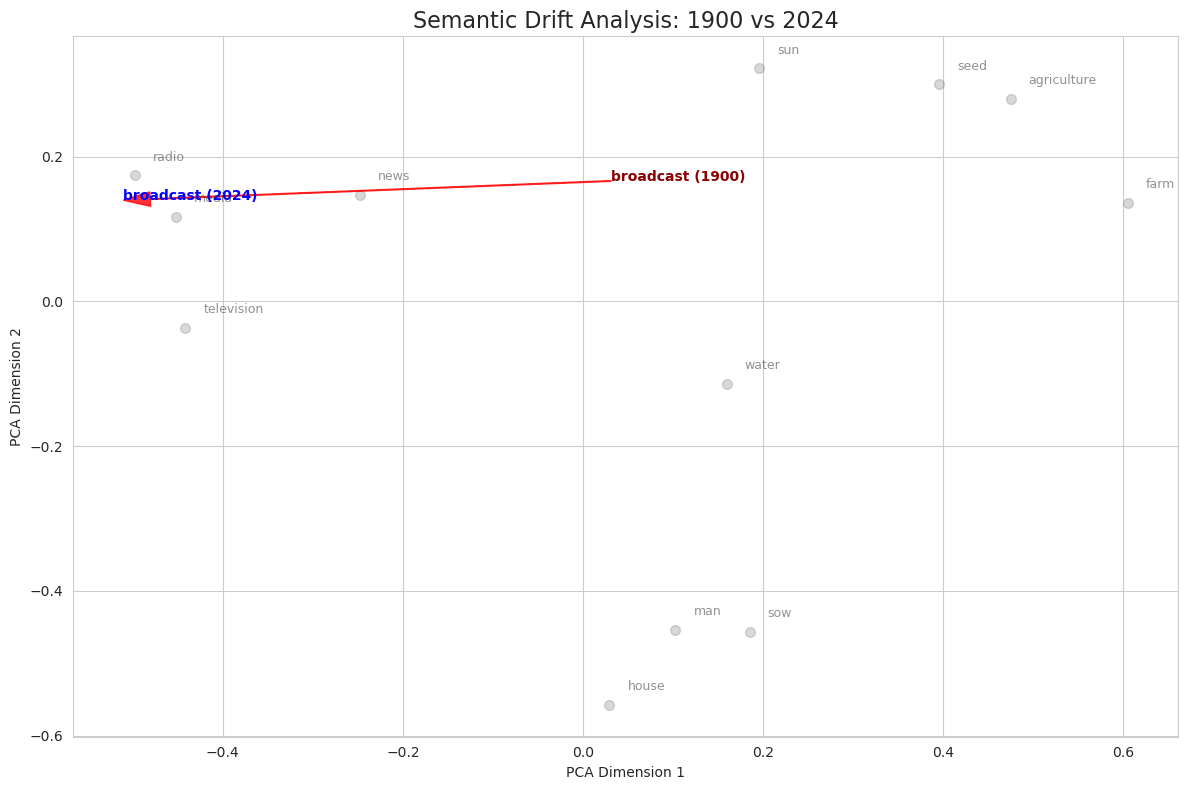

In [113]:
# 3. VISUALIZATION
# Choose a word that shifted, and anchors that represent its two possible meanings.
target = ["broadcast"]
anchors = ["seed", "farm", "agriculture", "sow", # 1900 context
           "radio", "television", "media", "news", # 2024 context
           "water", "sun", "man", "house"] # Neutral controls

plot_semantic_trajectory(mod_mod, mod_old, Rotation, target, anchors)

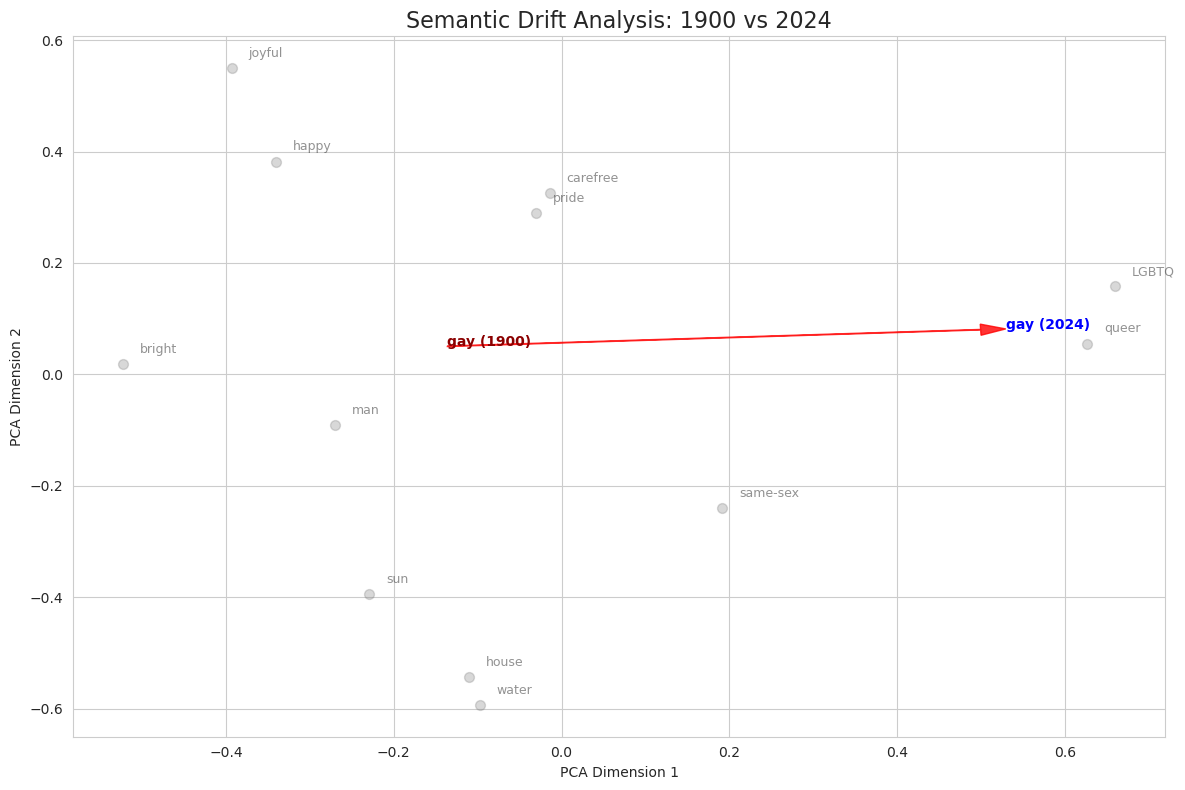

In [114]:
target = ["gay"]
anchors = [
    "joyful", "carefree", "bright", "happy",  # 1900 context
    "LGBTQ", "pride", "same-sex", "queer",    # 2024 context
    "water", "sun", "man", "house"             # Neutral controls
]

plot_semantic_trajectory(mod_mod, mod_old, Rotation, target, anchors)


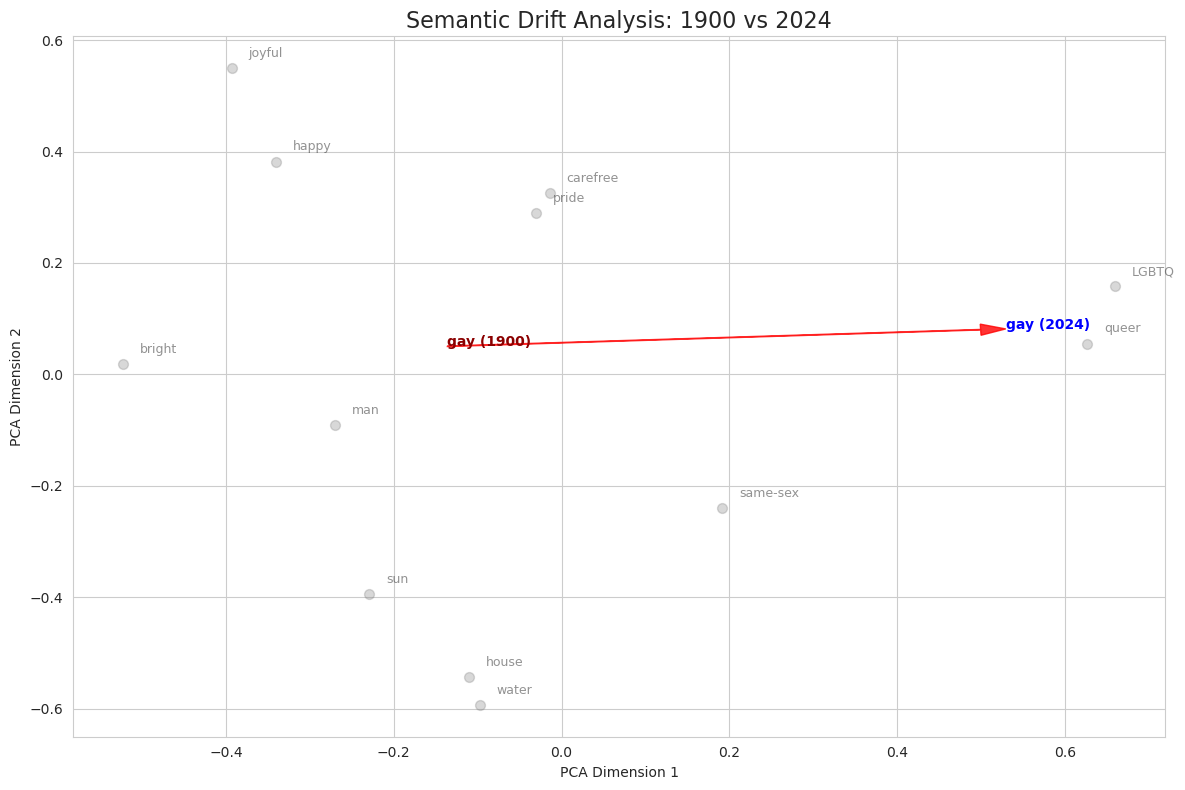

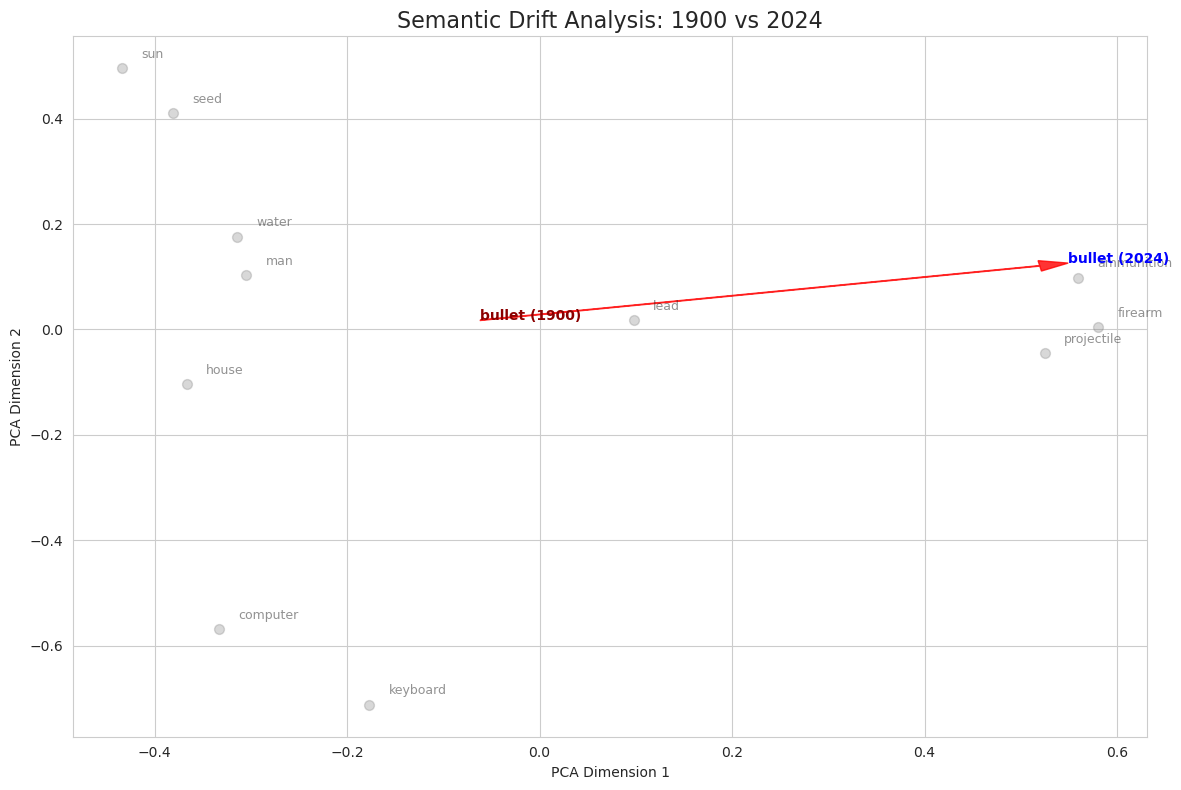

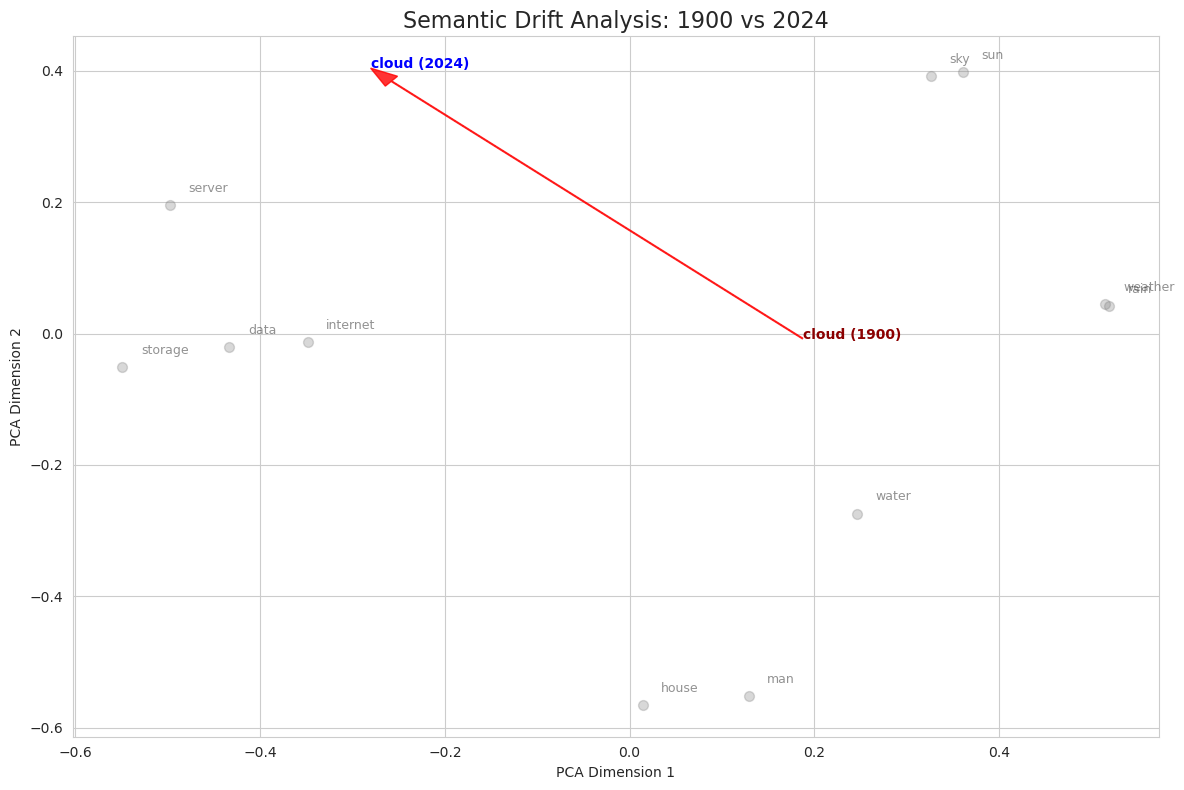

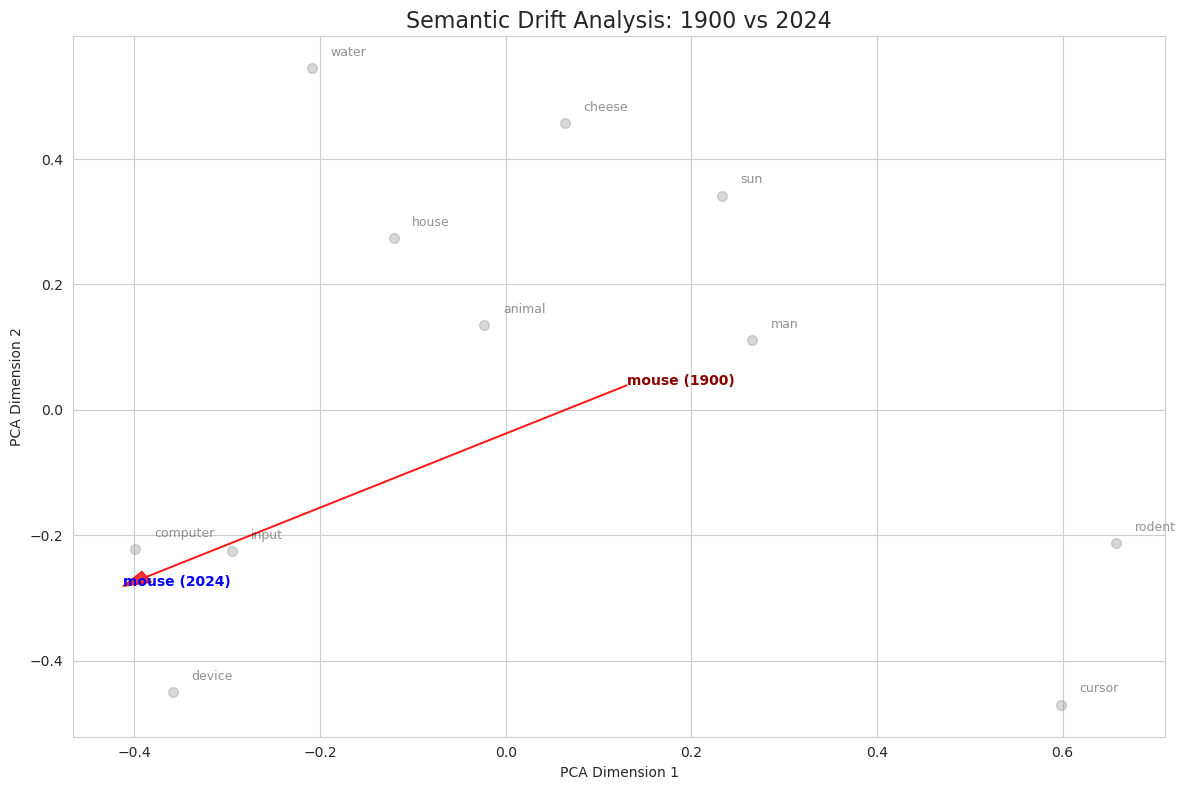

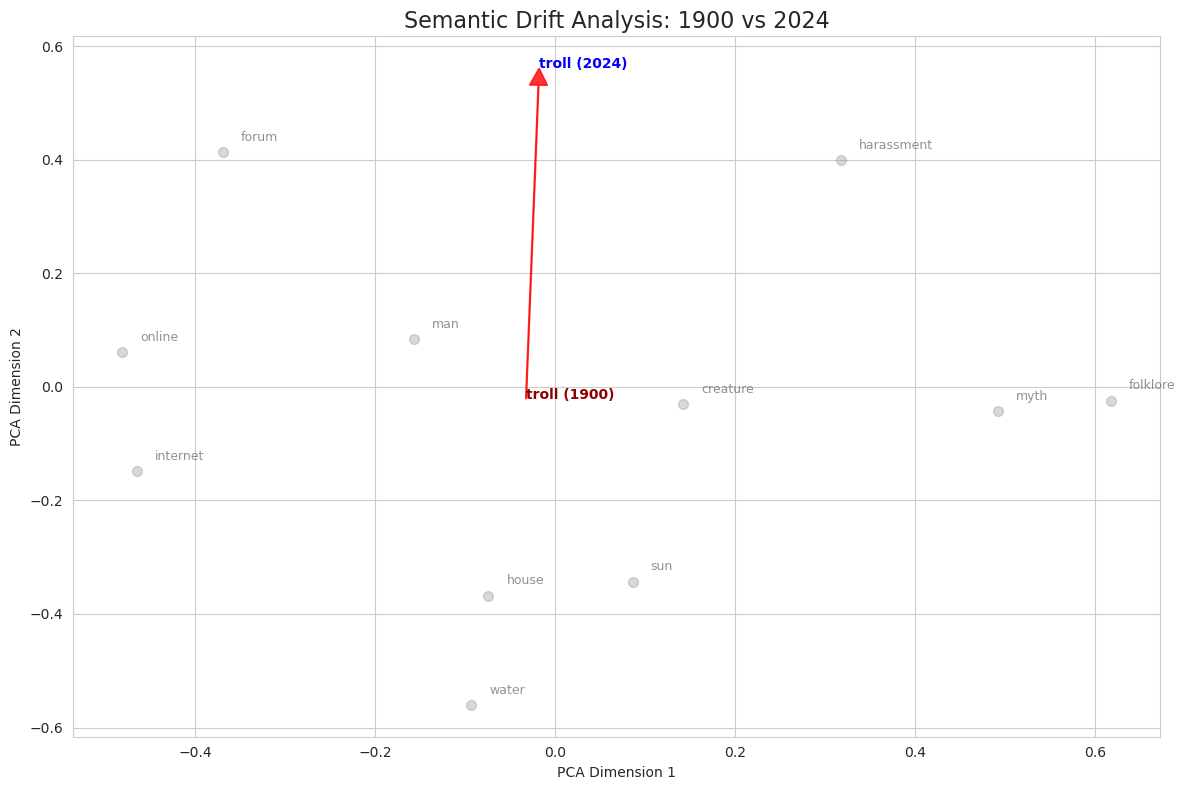

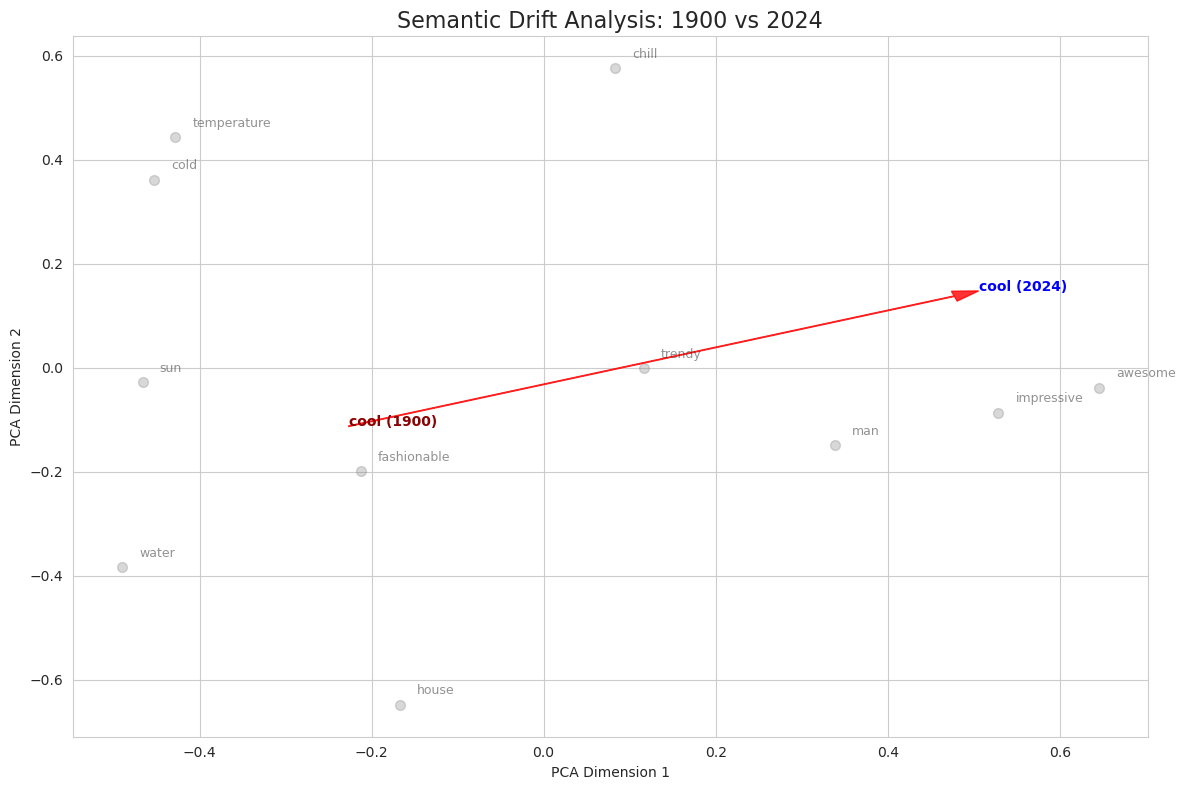

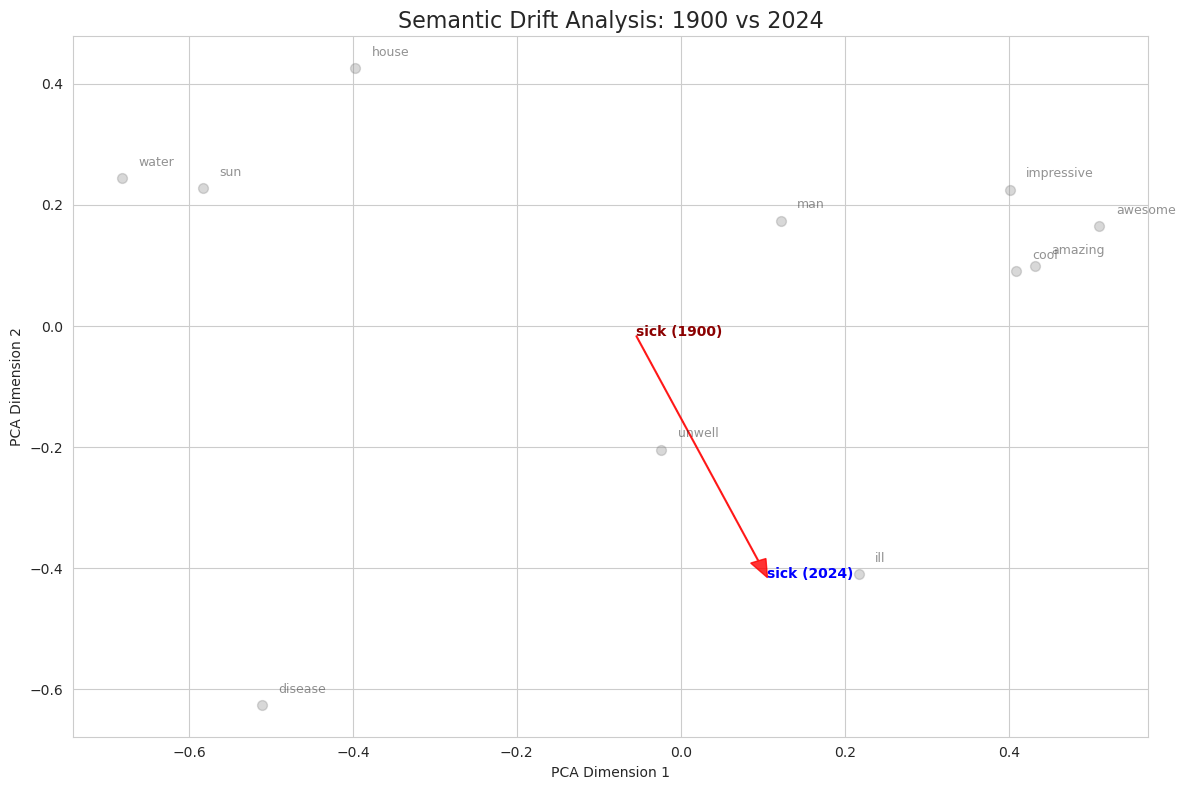

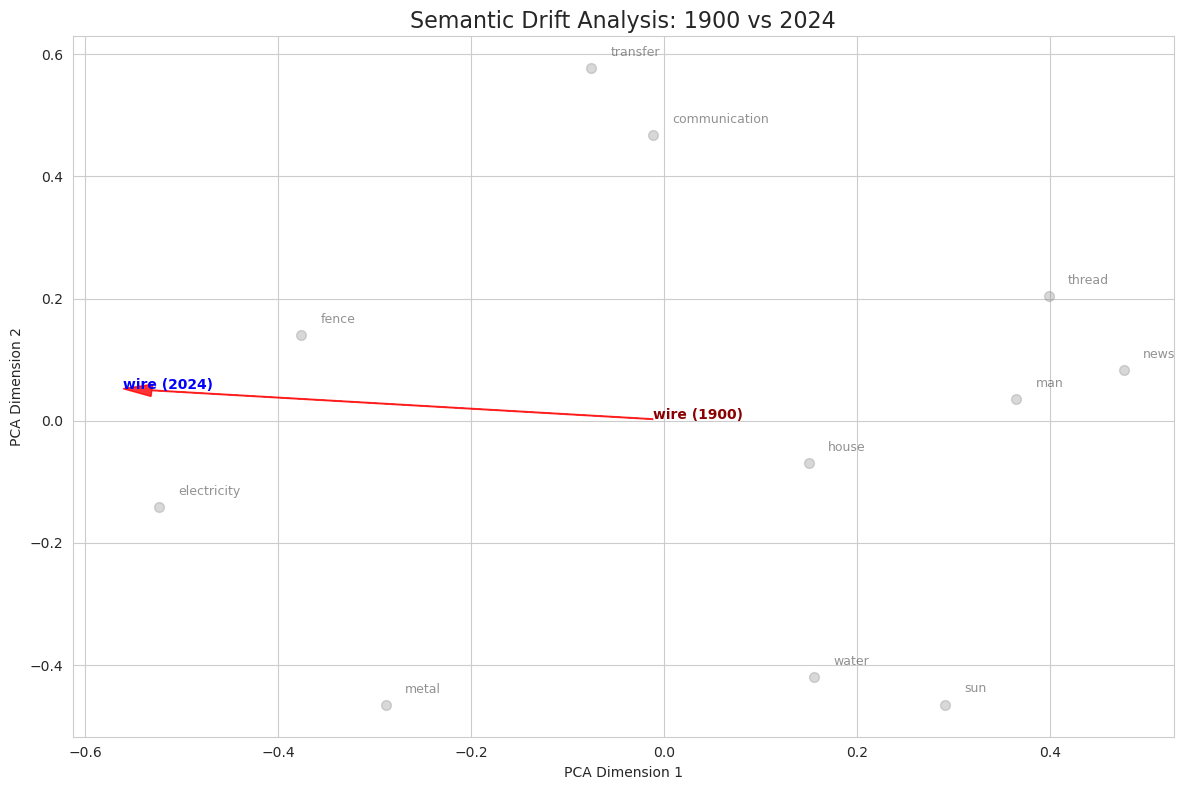

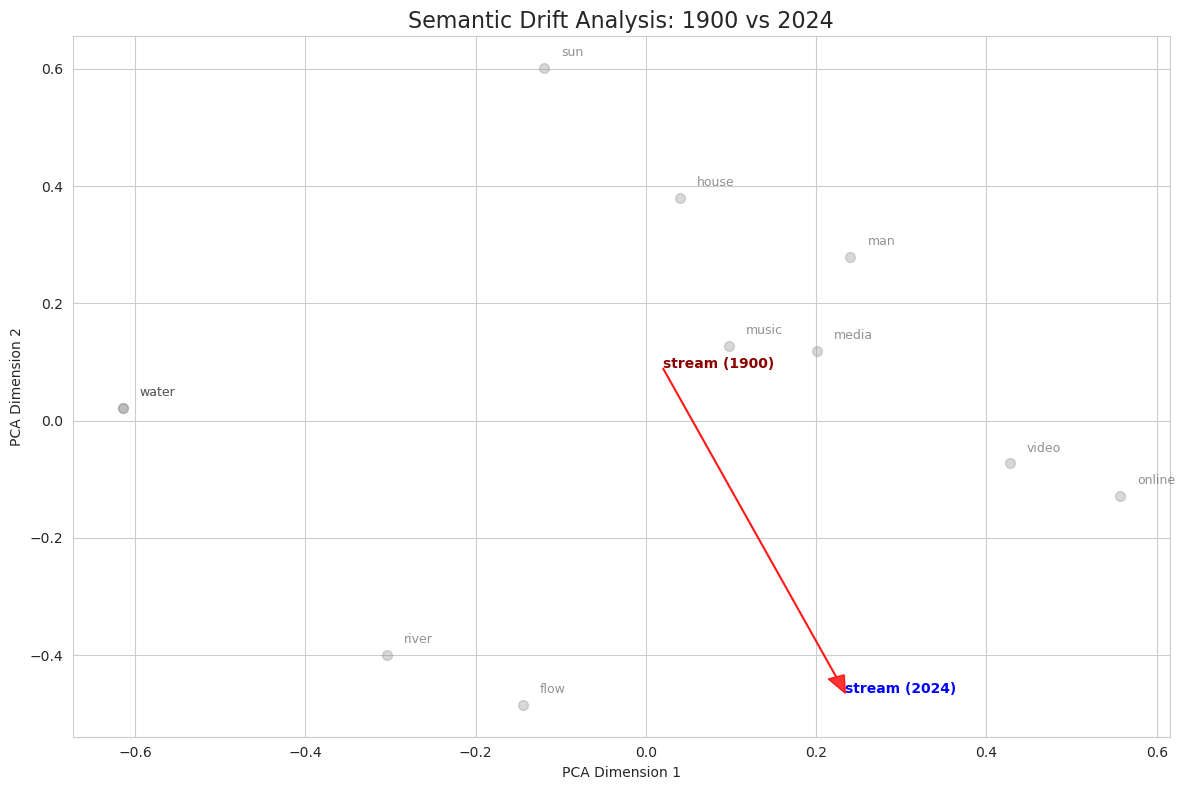

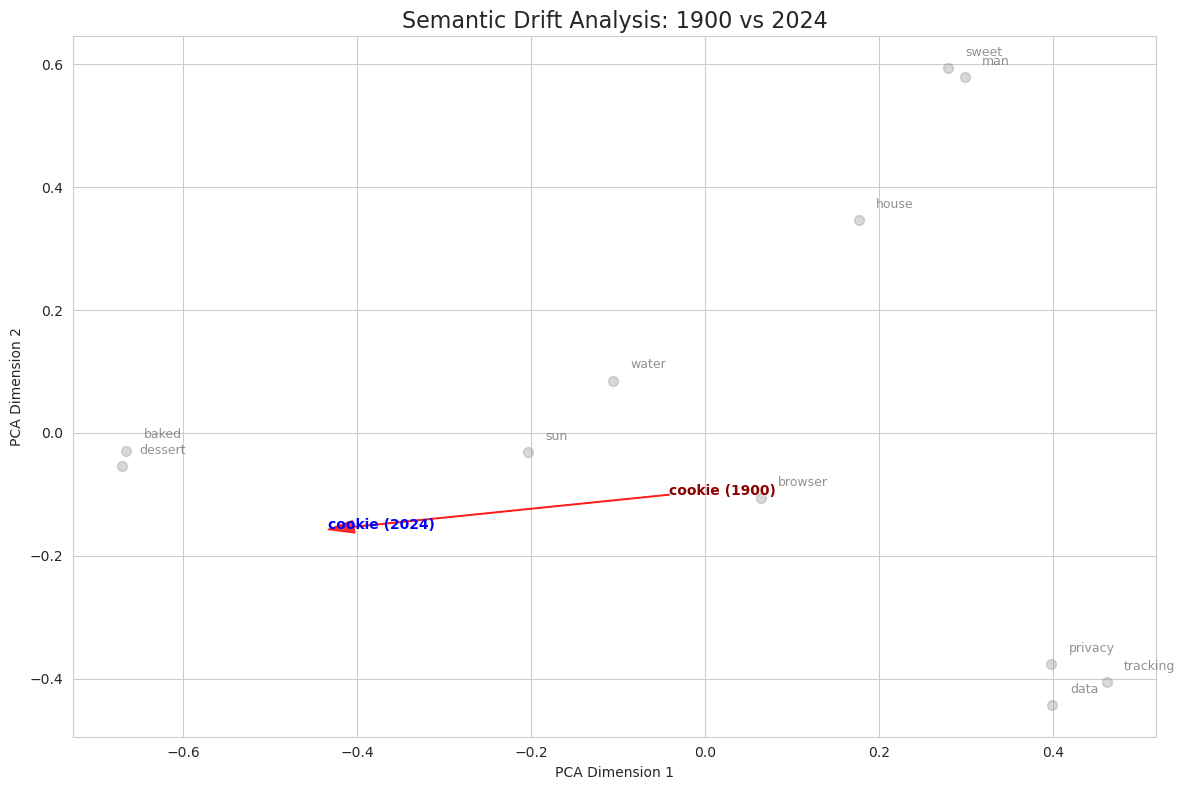

In [115]:
target_words = ["gay", "bullet", "cloud", "mouse", "troll", "cool", "sick", "wire", "stream", "cookie"]

anchors = {
    "gay": ["joyful", "carefree", "bright", "happy", "LGBTQ", "pride", "same-sex", "queer", "water", "sun", "man", "house"],
    "bullet": ["seed", "lead", "projectile", "firearm", "ammunition", "computer", "keyboard", "water", "sun", "man", "house"],
    "cloud": ["sky", "weather", "rain", "storage", "internet", "data", "server", "water", "sun", "man", "house"],
    "mouse": ["rodent", "animal", "cheese", "computer", "input", "device", "cursor", "water", "sun", "man", "house"],
    "troll": ["myth", "folklore", "creature", "internet", "harassment", "forum", "online", "water", "sun", "man", "house"],
    "cool": ["temperature", "chill", "cold", "fashionable", "impressive", "awesome", "trendy", "water", "sun", "man", "house"],
    "sick": ["ill", "disease", "unwell", "impressive", "awesome", "cool", "amazing", "water", "sun", "man", "house"],
    "wire": ["metal", "thread", "fence", "electricity", "communication", "transfer", "news", "water", "sun", "man", "house"],
    "stream": ["river", "water", "flow", "media", "video", "music", "online", "water", "sun", "man", "house"],
    "cookie": ["baked", "sweet", "dessert", "data", "browser", "tracking", "privacy", "water", "sun", "man", "house"]
}

# Plot for each target word
for target in target_words:
    plot_semantic_trajectory(mod_mod, mod_old, Rotation, [target], anchors[target])


In [92]:
print(text_blob[:1_000])

sometimes on opening his eyes he would find her asleep, but with traces of tears on her face, showing that she had been awake and crying. one afternoon, seeing him tired of play and hard to amuse, she took him in her arms and carried him right up the side of the mountain, where it grew so steep that even the big cat could not follow them. finally she brought him out on the extreme summit, and looking round he seemed to see the whole world spread out beneath him. below, half - way down, there were some wild cattle feeding on the mountain side, and they looked at that distance no bigger than mice a prince as hardicanute ; he therefore appointed by his will harold successor to the crown. this prince was, besides, present to maintain his claim ; he was favoured by all the danes, and he got immediately possession of his father ' s treasures, which might be equally useful, whether he found it necessary to proceed by force or intrigue in insuring his succession. on the other hand, hardicanute

In [ ]:
from datasets import load_from_disk
from transformers import AutoTokenizer

# 1. Load your processed data
dataset = load_from_disk("data/pg19_processed_tokens")
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

# 2. Decode a subset to check probe frequency
print("Counting all occurences of words..")
subset = dataset.shuffle(seed=42).select(range(int(ds_size)))
text_blob = tokenizer.batch_decode(subset["input_ids"])
text_blob = " ".join(text_blob).lower()

# 3. Check your probe words
probes = ["broadcast", "monitor", "mouse", "intercourse", 
          "toilet", "traffic", "gay", "consumption",
          "cloud", "web", "cloud", "bug", "troll", "bullet", "like",
          "viral", "spam", "ghost", "qeer", 
          ]

print(f"{'WORD':<15} | {'COUNT':<10} | {'VERDICT'}")
print("-" * 40)
for p in probes:
    count = text_blob.count(f" {p} ") # spaces ensure we match whole words
    verdict = "✅ Good" if count > 50 else "❌ Too Rare"
    print(f"{p:<15} | {count:<10} | {verdict}")#

Counting all occurences of words..
WORD            | COUNT      | VERDICT
----------------------------------------
broadcast       | 27         | ❌ Too Rare
monitor         | 65         | ✅ Good
mouse           | 284        | ✅ Good
intercourse     | 777        | ✅ Good
toilet          | 98         | ✅ Good
traffic         | 390        | ✅ Good
gay             | 1406       | ✅ Good
consumption     | 253        | ✅ Good
cloud           | 1366       | ✅ Good
web             | 191        | ✅ Good
cloud           | 1366       | ✅ Good
bug             | 71         | ✅ Good
troll           | 25         | ❌ Too Rare
bullet          | 431        | ✅ Good
like            | 49174      | ✅ Good
viral           | 0          | ❌ Too Rare
spam            | 0          | ❌ Too Rare
ghost           | 680        | ✅ Good


In [85]:
for p in probes:
    count = text_blob.count(f" {p} ") # spaces ensure we match whole words
    verdict = "✅ Good" if count > 50 else "❌ Too Rare"
    print(f"{p:<15} | {count:<10} | {verdict}")#
good_candidates = [p for p in probes if text_blob.count(f" {p} ") > 50]

broadcast       | 27         | ❌ Too Rare
monitor         | 65         | ✅ Good
mouse           | 284        | ✅ Good
intercourse     | 777        | ✅ Good
toilet          | 98         | ✅ Good
traffic         | 390        | ✅ Good
gay             | 1406       | ✅ Good
consumption     | 253        | ✅ Good
cloud           | 1366       | ✅ Good
web             | 191        | ✅ Good
cloud           | 1366       | ✅ Good
bug             | 71         | ✅ Good
troll           | 25         | ❌ Too Rare
bullet          | 431        | ✅ Good
like            | 49174      | ✅ Good
viral           | 0          | ❌ Too Rare
spam            | 0          | ❌ Too Rare
ghost           | 680        | ✅ Good


In [116]:
import torch
import numpy as np
from model2vec import StaticModel
from scipy.spatial.distance import cdist

def get_nearest_neighbors(model, word, top_k=10):
    try:
        # 1. Encode the target word
        target_vec = model.encode([word]) # Shape (1, 384)
        
        # 2. Get the entire vocabulary and their vectors
        # Note: We extract the dictionary from the tokenizer
        vocab = list(model.tokenizer.get_vocab().keys())
        
        # Filter out subwords (tokens starting with ##) and short noise
        vocab = [w for w in vocab if len(w) > 3 and not w.startswith("##")]
        
        # This might be slow if vocab is huge, but fine for analysis
        # We batch encode to speed it up
        print(f"Scanning {len(vocab)} words in vocabulary...")
        all_vecs = model.encode(vocab)
        
        # 3. Calculate Cosine Distance (1 - Similarity)
        # cdist calculates distance between the target and ALL other words
        dists = cdist(target_vec, all_vecs, metric='cosine')[0]
        
        # 4. Sort and extract top K
        # We want the SMALLEST distance
        nearest_indices = np.argsort(dists)[:top_k]
        
        print(f"\n--- Neighbors for '{word}' ---")
        for i in nearest_indices:
            print(f"{vocab[i]:<15} (Dist: {dists[i]:.4f})")
            
    except KeyError:
        print(f"Word '{word}' not found in vocabulary.")

# --- RUN THE TEST ---
model_scratch = StaticModel.from_pretrained("models/pg19_scratch_static_final")
model_scratch = StaticModel.from_pretrained("models/pg19_aggressive_static_final")
#model_scratch = StaticModel.from_pretrained("models/pg19_static_final")
model_modern = StaticModel.from_pretrained("models/all-MiniLM-L6-v2_static")
# Check the drifters
for candidate in good_candidates:
    print(f"\n== Nearest Neighbors for '{candidate}':")
    print("-> Scratch Model:")
    get_nearest_neighbors(model_scratch, candidate)
    print("-> Modern Model:")
    get_nearest_neighbors(model_modern, candidate)


== Nearest Neighbors for 'monitor':
-> Scratch Model:
Scanning 25027 words in vocabulary...

--- Neighbors for 'monitor' ---
▁monitor        (Dist: 0.0000)
▁monitors       (Dist: 0.1892)
▁lcd            (Dist: 0.2970)
▁screen         (Dist: 0.3150)
screen          (Dist: 0.3150)
▁display        (Dist: 0.3530)
▁monitoring     (Dist: 0.3538)
▁monitored      (Dist: 0.3833)
▁television     (Dist: 0.4154)
▁scanner        (Dist: 0.4224)
-> Modern Model:
Scanning 25027 words in vocabulary...

--- Neighbors for 'monitor' ---
▁monitor        (Dist: 0.0000)
▁monitors       (Dist: 0.1095)
▁displays       (Dist: 0.2871)
▁screens        (Dist: 0.3365)
screen          (Dist: 0.3649)
▁screen         (Dist: 0.3649)
▁lcd            (Dist: 0.4080)
▁display        (Dist: 0.4092)
▁monitoring     (Dist: 0.4245)
▁monitored      (Dist: 0.4479)

== Nearest Neighbors for 'mouse':
-> Scratch Model:
Scanning 25027 words in vocabulary...

--- Neighbors for 'mouse' ---
▁mouse          (Dist: 0.0000)
▁mice        

In [ ]:
# good words --> cloud, gay, traffic, intercourse,

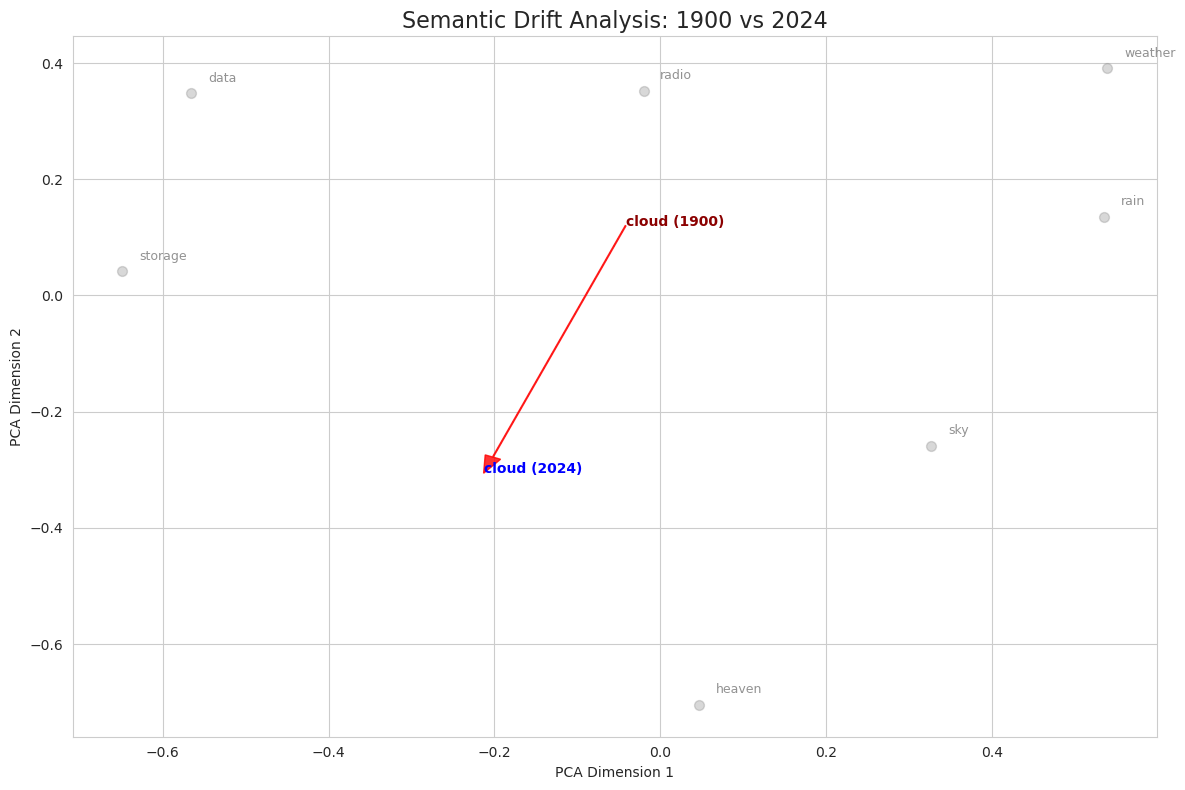

In [117]:
plot_semantic_trajectory(model_modern, model_scratch, Rotation, ['cloud'], ['sky', 'heaven', 'weather', 'data', 'storage', 'radio', 'rain',])

Loading models...
Common vocabulary size: 27007
Alignment rotation calculated.


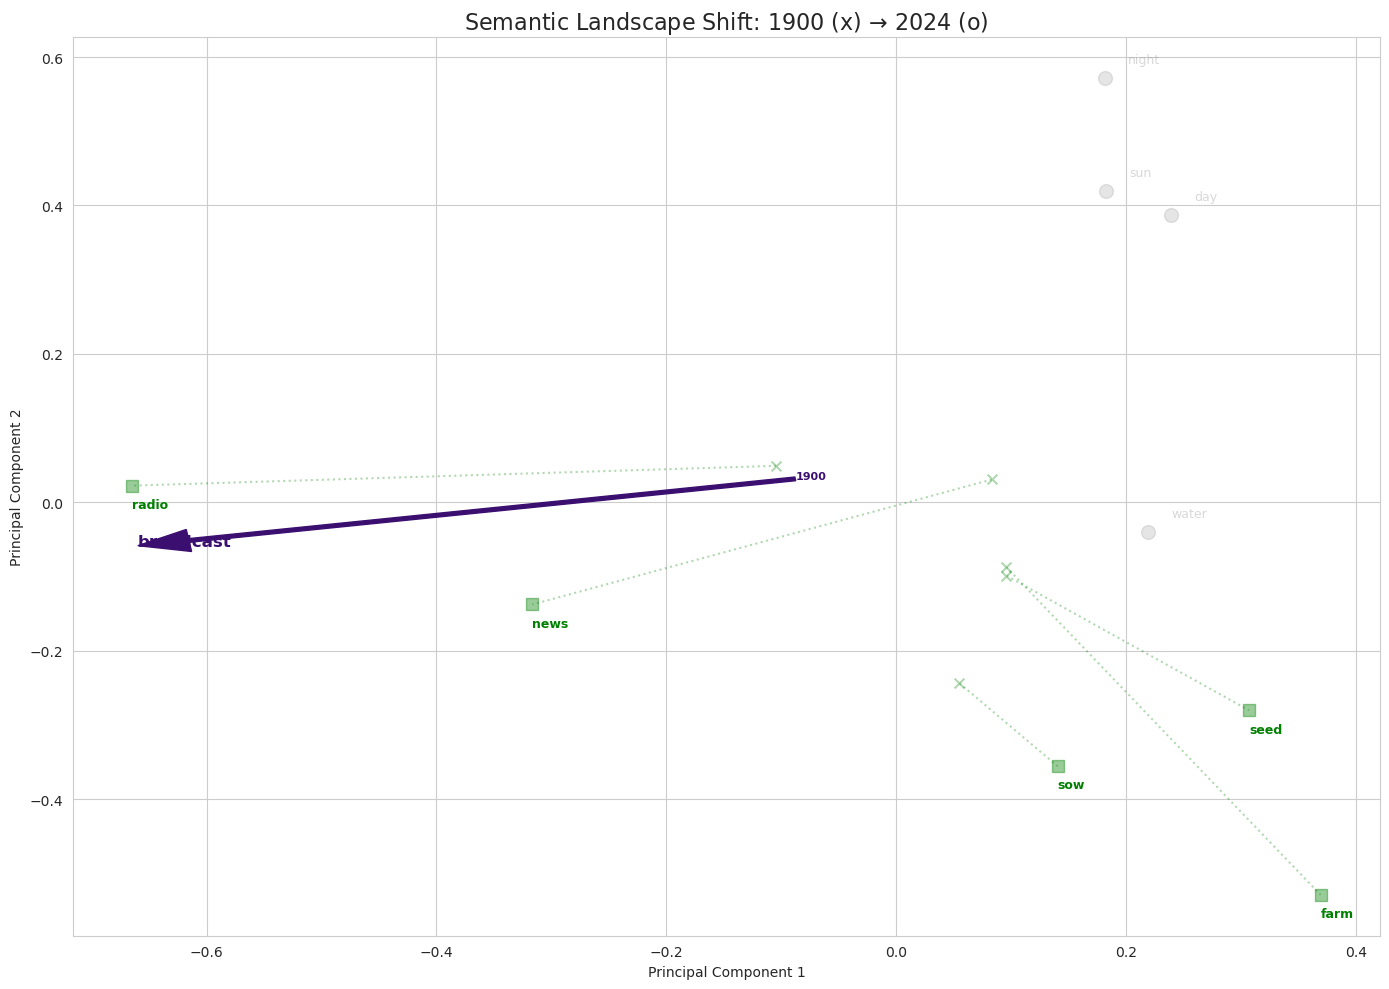

In [118]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from model2vec import StaticModel
from scipy.linalg import orthogonal_procrustes

# [Keep your existing load_and_align_models function]

def plot_semantic_trajectory_v2(mod_modern, mod_pg19, R, target_words, context_anchors, control_anchors):
    """
    Plots the movement of target words AND context words to show landscape shifts.
    
    Args:
        target_words: The main drifters (e.g., "broadcast")
        context_anchors: Words defining the meanings (e.g., "farm", "radio")
        control_anchors: Stable words defining the map (e.g., "water", "sun")
    """
    plt.figure(figsize=(14, 10))
    sns.set_style("whitegrid")
    
    # 1. Define the Coordinate System (The "Map")
    # We build the PCA map using ONLY the Modern vectors of all words.
    # This keeps the axes consistent: X-axis = "Modern Meaning Dimension 1"
    all_words = list(set(target_words + context_anchors + control_anchors))
    base_vectors = mod_modern.encode(all_words)
    
    pca = PCA(n_components=2)
    pca.fit(base_vectors) # Fit the "Modern World" coordinates
    
    # Helper to plot a single point
    def get_pos(model, word, rotation=None):
        vec = model.encode([word])[0]
        if rotation is not None:
            vec = vec @ rotation # Align PG19 to Modern
        return pca.transform([vec])[0]

    # 2. Plot Stable Controls (Grey Background)
    # We assume these are static, so we just plot the Modern position to reduce clutter
    for word in control_anchors:
        pos = get_pos(mod_modern, word)
        plt.scatter(pos[0], pos[1], alpha=0.2, color='gray', s=100)
        plt.text(pos[0]+0.02, pos[1]+0.02, word, alpha=0.3, fontsize=9, color='gray')

    # 3. Plot Context Anchors (The Changing Landscape)
    # We show where "Radio" was in 1900 vs 2024
    for word in context_anchors:
        # Modern Position (The "Target" Meaning)
        pos_mod = get_pos(mod_modern, word)
        plt.scatter(pos_mod[0], pos_mod[1], marker='s', color='green', alpha=0.4, s=80)
        plt.text(pos_mod[0], pos_mod[1]-0.03, f"{word}", fontsize=9, color='green', fontweight='bold')
        
        # PG-19 Position (Does this concept even exist?)
        pos_old = get_pos(mod_pg19, word, rotation=R)
        
        # Draw a faint dotted line connecting them to show context drift
        plt.plot([pos_old[0], pos_mod[0]], [pos_old[1], pos_mod[1]], 
                 linestyle=':', color='green', alpha=0.3)
        plt.scatter(pos_old[0], pos_old[1], marker='x', color='green', alpha=0.3, s=50)

    # 4. Plot Target Trajectories (The Main Event)
    colors = plt.cm.magma(np.linspace(0.2, 0.8, len(target_words)))
    
    for i, word in enumerate(target_words):
        pos_mod = get_pos(mod_modern, word)
        pos_old = get_pos(mod_pg19, word, rotation=R)
        
        # Draw bold arrow
        plt.arrow(pos_old[0], pos_old[1], 
                  pos_mod[0]-pos_old[0], pos_mod[1]-pos_old[1], 
                  head_width=0.03, color=colors[i], alpha=1.0, width=0.005, length_includes_head=True, zorder=10)
        
        # Labels
        plt.text(pos_old[0], pos_old[1], f"1900", color=colors[i], fontsize=8, fontweight='bold')
        plt.text(pos_mod[0], pos_mod[1], f"{word}", color=colors[i], fontsize=12, fontweight='bold')

    plt.title("Semantic Landscape Shift: 1900 (x) $\u2192$ 2024 (o)", fontsize=16)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.tight_layout()
    plt.show()

# --- EXECUTION EXAMPLE ---

# Run the alignment first (from your script)
mod_mod, mod_old, Rotation, common_vocab = load_and_align_models()

# Plot Broadcast
target = ["broadcast"]
context_anchors = ["farm", "seed", "sow",    # Farming Context
                   "radio", "news"]          # Tech Context (Expect these to move or represent noise in 1900)
control_anchors = ["water", "sun", "day", "night"]

plot_semantic_trajectory_v2(mod_mod, mod_old, Rotation, target, context_anchors, control_anchors)

Aligning models using 95 strict anchors...


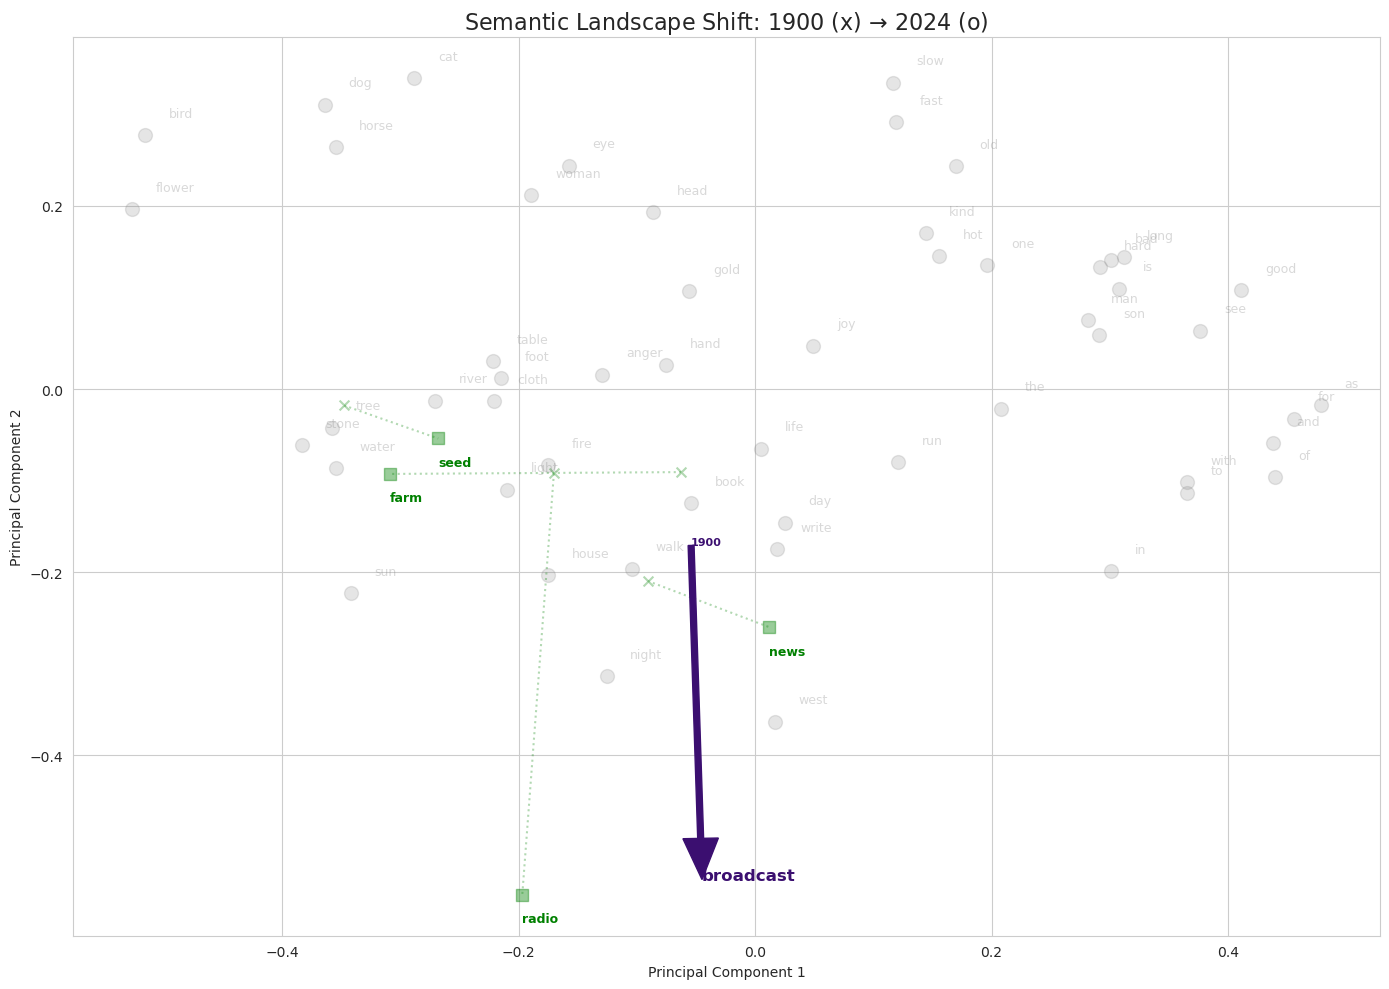

In [119]:
import numpy as np
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes

# 1. Define the "Gold Standard" Anchors (Immutable Concepts)
# These words are extremely unlikely to have drifted.
STABLE_ANCHORS = [
    # Feelings
    "love", "hate", "joy", "fear", "anger", "sadness", "pain", "pleasure", "friend", "enemy",
    "happy", "sad", "good", "bad", "brave", "strong", "weak", "kind",
    # Attributes
    "big", "small", "long", "short", "hot", "cold", "old", "new", "fast", "slow",
    "light", "dark", "hard", "soft", "heavy", "thin",
    # Basic Objects
    "house", "chair", "table", "flower", "cloth", "horse", "dog", "cat", "book", "bird",
    # Physical World
    "sun", "moon", "water", "fire", "river", "mountain", "tree", "stone", "gold", "silver",
    "night", "day", "summer", "winter", "north", "south", "east", "west",
    # Basic Human
    "hand", "foot", "head", "eye", "mother", "father", "son", "daughter", "man", "woman",
    "life", "death", "sleep", "eat", "drink", "walk", "run", "speak", "write", "see",
    # Abstract/Grammar (High Frequency)
    "the", "and", "of", "to", "in", "is", "that", "with", "for", "as", "one", "two", "three"
]

def align_strictly_and_plot(mod_modern, mod_pg19, target_words, context_words):
    """
    Aligns vectors using ONLY the Stable Anchor list, then projects the target/context words.
    """
    
    # --- STEP 1: CALCULATE ROTATION (Using only STABLE words) ---
    print(f"Aligning models using {len(STABLE_ANCHORS)} strict anchors...")
    
    # Filter anchors to ensure they exist in both models
    valid_anchors = [w for w in STABLE_ANCHORS 
                     if w in mod_modern.tokenizer.get_vocab() 
                     and w in mod_pg19.tokenizer.get_vocab()]
    
    # Encode Anchors
    vecs_mod = mod_modern.encode(valid_anchors)
    vecs_old = mod_pg19.encode(valid_anchors)
    
    # Calculate Rotation Matrix R
    # This aligns the "Background Reality" of 1900 to 2024
    R, _ = orthogonal_procrustes(vecs_old, vecs_mod)
    
    # --- STEP 2: APPLY ROTATION TO TARGETS ---
    # Now we project the "Context" words. 
    # Because we didn't use them to align, their movement is GENUINE.
    
    # (Reuse the plotting code from the previous response here)
    # When plotting, use the R we just calculated.
    plot_semantic_trajectory_v2(
        mod_modern, 
        mod_pg19, 
        R,             # The strict rotation
        target_words, 
        context_words, 
        valid_anchors  # Plot anchors lightly as background
    )

# Example Usage
align_strictly_and_plot(
    mod_modern=mod_mod, 
    mod_pg19=mod_old, 
    target_words=["broadcast"], 
    context_words=["farm", "seed", "radio", "news"]
)

Loading Models...


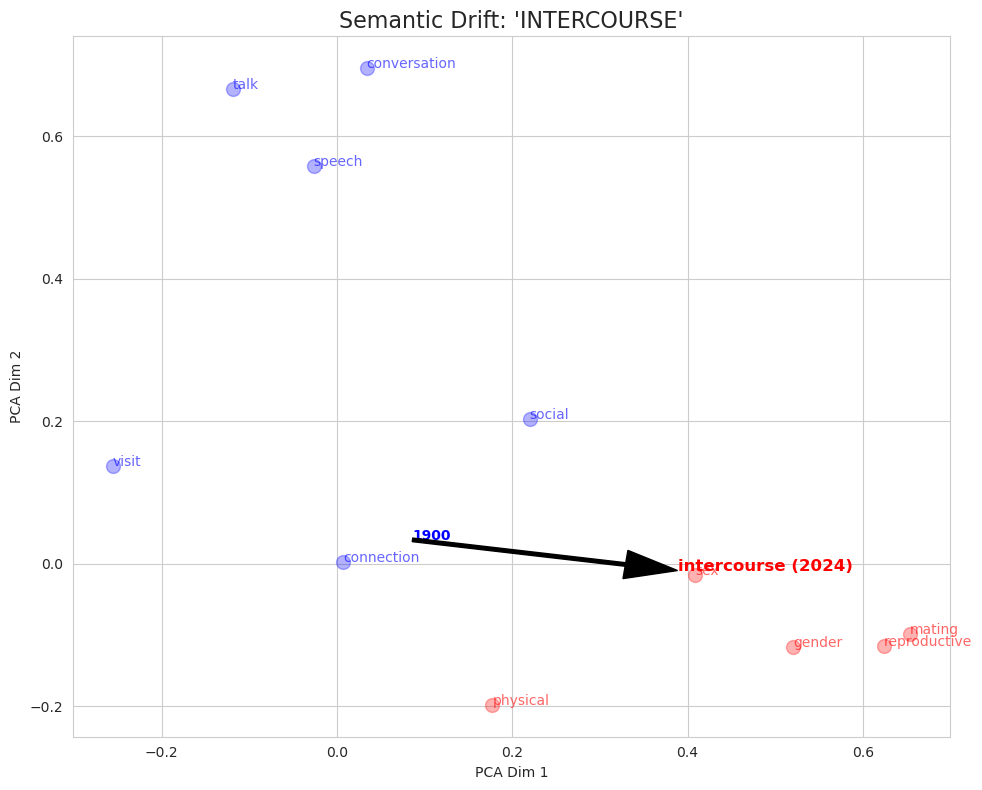

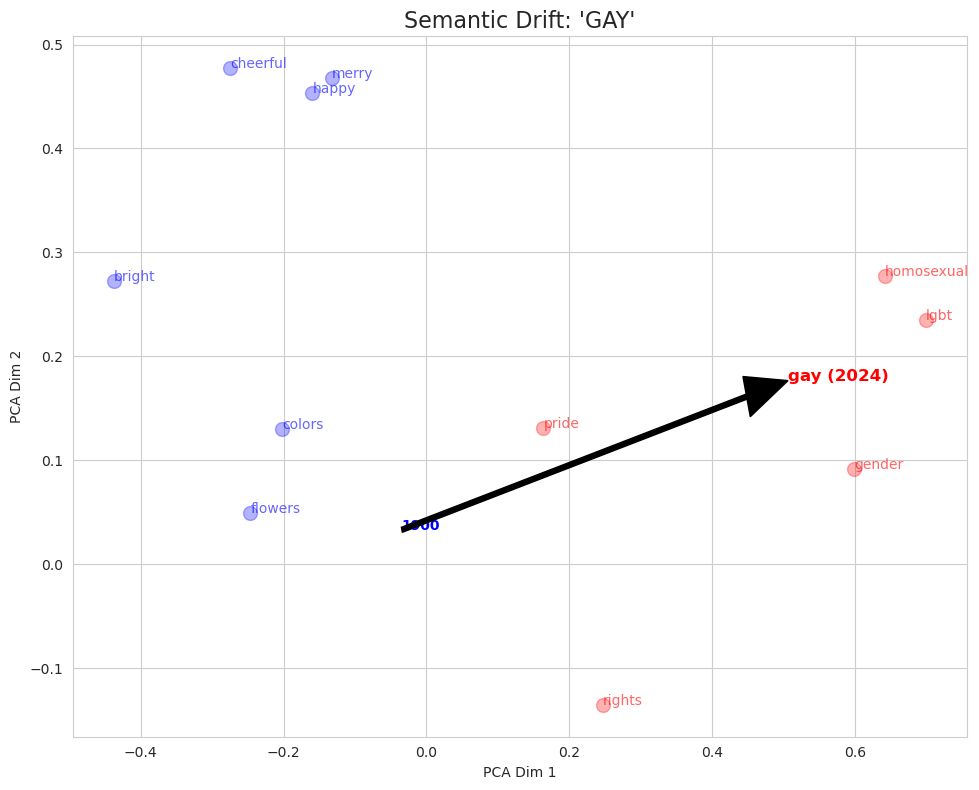

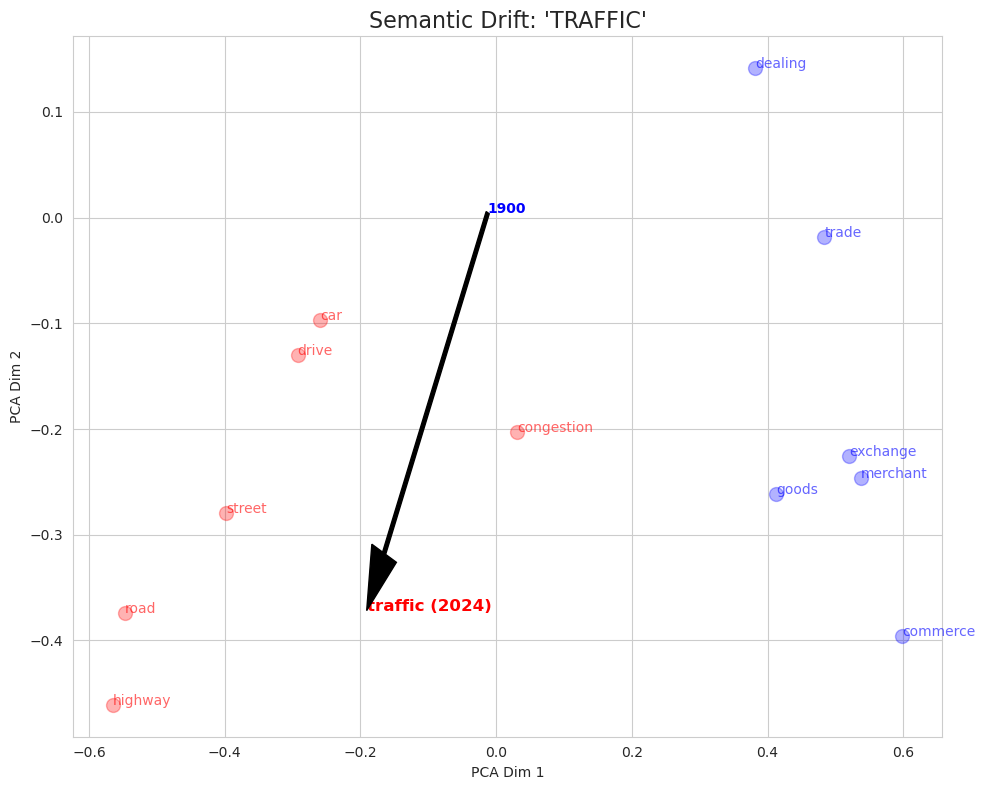

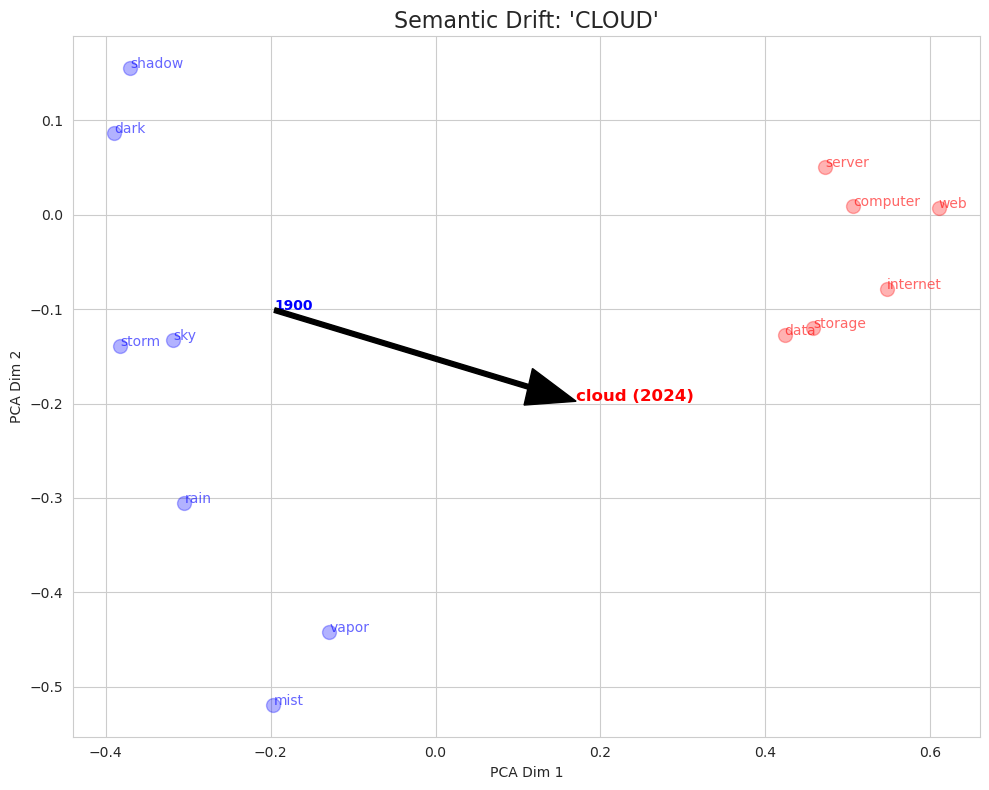

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
from model2vec import StaticModel

# --- 1. CONFIGURATION ---
MODERN_PATH_ALL_MINILM = "minishlab/potion-base-8m"           # Base Model from library
MODERN_PATH_ALL_MINILM = "models/all-MiniLM-L6-v2_static"          # Base Model from sentence-transformers
PG19_PRE_TRAINED_FROM_SCRATCH_PATH   = "models/pg19_scratch_static_final"   #  Fine-Tuned Model
PG19_WEAK_FINE_TUNED_PATH   = "models/pg19_static_final"   #  Fine-Tuned Model
PG19_AGGRESSIVE_FINE_TUNED_PATH   = "models/pg19_aggressive_static_final"   #  Fine-Tuned Model

# "Strict Anchors" - Words that definitely did NOT change.
# We use these to lock the two coordinate systems together.
STABLE_ANCHORS = [
    "sun", "moon", "water", "river", "mountain", "stone", "night", "day",
    "summer", "winter", "north", "south", "east", "west", "hand", "foot",
    "head", "mother", "father", "son", "daughter", "man", "woman", "life",
    "death", "eat", "drink", "walk", "speak", "the", "and", "of", "to"
]

# --- 2. ALIGNMENT & PLOTTING ENGINE ---

def plot_drift(mod_modern, mod_pg19, target_word, old_context, new_context):
    """
    Aligns the 1900 model to the 2024 model using Stable Anchors,
    then plots the specific drift of the target word.
    """
    
    # A. Align Models (Procrustes)
    # ---------------------------
    # Only use words that exist in both vocabularies
    valid_anchors = [w for w in STABLE_ANCHORS 
                     if w in mod_modern.tokenizer.get_vocab() 
                     and w in mod_pg19.tokenizer.get_vocab()]
    
    vecs_mod = mod_modern.encode(valid_anchors)
    vecs_old = mod_pg19.encode(valid_anchors)
    
    # Calculate Rotation Matrix R (Aligns Old -> Modern)
    R, _ = orthogonal_procrustes(vecs_old, vecs_mod)
    
    # B. Setup Plotting Data
    # ----------------------
    # We build the map using Modern vectors for context words
    all_context = old_context + new_context + valid_anchors[:10] # Add some anchors for background
    base_vectors = mod_modern.encode(all_context)
    
    # Fit PCA on the Modern Contexts (This defines the "2024 Map")
    pca = PCA(n_components=2)
    pca.fit(base_vectors)
    
    plt.figure(figsize=(10, 8))
    sns.set_style("whitegrid")
    
    # Helper to project words into 2D
    def get_pos(model, word, rotation=None):
        vec = model.encode([word])[0]
        if rotation is not None:
            vec = vec @ R # Apply alignment
        return pca.transform([vec])[0]

    # C. Plot The Map (Context Clusters)
    # --------------------------------
    # 1. Plot Old Contexts (e.g. "Conversation") - Blue
    for w in old_context:
        pos = get_pos(mod_modern, w)
        plt.scatter(pos[0], pos[1], c='blue', alpha=0.3, s=100)
        plt.text(pos[0], pos[1], w, color='blue', alpha=0.6, fontsize=10)

    # 2. Plot New Contexts (e.g. "Sex") - Red
    for w in new_context:
        pos = get_pos(mod_modern, w)
        plt.scatter(pos[0], pos[1], c='red', alpha=0.3, s=100)
        plt.text(pos[0], pos[1], w, color='red', alpha=0.6, fontsize=10)

    # D. Plot The Drifting Target
    # -------------------------
    # 1. Start Position (1900)
    pos_start = get_pos(mod_pg19, target_word, rotation=R)
    
    # 2. End Position (2024)
    pos_end = get_pos(mod_modern, target_word)
    
    # Draw Arrow
    plt.arrow(pos_start[0], pos_start[1], 
              pos_end[0]-pos_start[0], pos_end[1]-pos_start[1], 
              head_width=0.04, color='black', width=0.005, length_includes_head=True, zorder=10)
    
    plt.text(pos_start[0], pos_start[1], "1900", color='blue', fontweight='bold', fontsize=10)
    plt.text(pos_end[0], pos_end[1], f"{target_word} (2024)", color='red', fontweight='bold', fontsize=12)
    
    plt.title(f"Semantic Drift: '{target_word.upper()}'", fontsize=16)
    plt.xlabel("PCA Dim 1")
    plt.ylabel("PCA Dim 2")
    plt.tight_layout()
    plt.show()

# --- 3. EXECUTION ---

print("Loading Models...")
model_modern = StaticModel.from_pretrained(MODERN_PATH)
model_pg19 = StaticModel.from_pretrained(PG19_PATH)

# --- 4. RUN ANALYSIS FOR YOUR WORDS ---

# 1. INTERCOURSE (The clearest example)
# Moves from "Conversation" -> "Sex"
plot_drift(
    model_modern, model_pg19,
    target_word="intercourse",
    old_context=["conversation", "social", "speech", "talk", "visit", "connection"],
    new_context=["sex", "physical", "reproductive", "mating", "gender"]
)

# 2. GAY
# Moves from "Happy" -> "Homosexual"
plot_drift(
    model_modern, model_pg19,
    target_word="gay",
    old_context=["happy", "bright", "merry", "cheerful", "flowers", "colors"],
    new_context=["homosexual", "lgbt", "rights", "gender", "pride"]
)

# 3. TRAFFIC
# Moves from "Trade/Dealing" -> "Cars/Roads"
plot_drift(
    model_modern, model_pg19,
    target_word="traffic",
    old_context=["trade", "commerce", "goods", "dealing", "exchange", "merchant"],
    new_context=["car", "road", "highway", "congestion", "drive", "street"]
)

# 4. CLOUD
# Moves from "Sky/Weather" -> "Internet/Data"
plot_drift(
    model_modern, model_pg19,
    target_word="cloud",
    old_context=["sky", "rain", "storm", "dark", "shadow", "vapor", "mist"],
    new_context=["computer", "server", "data", "internet", "storage", "web"]
)

Generating dashboard for Base: Potion-8M...


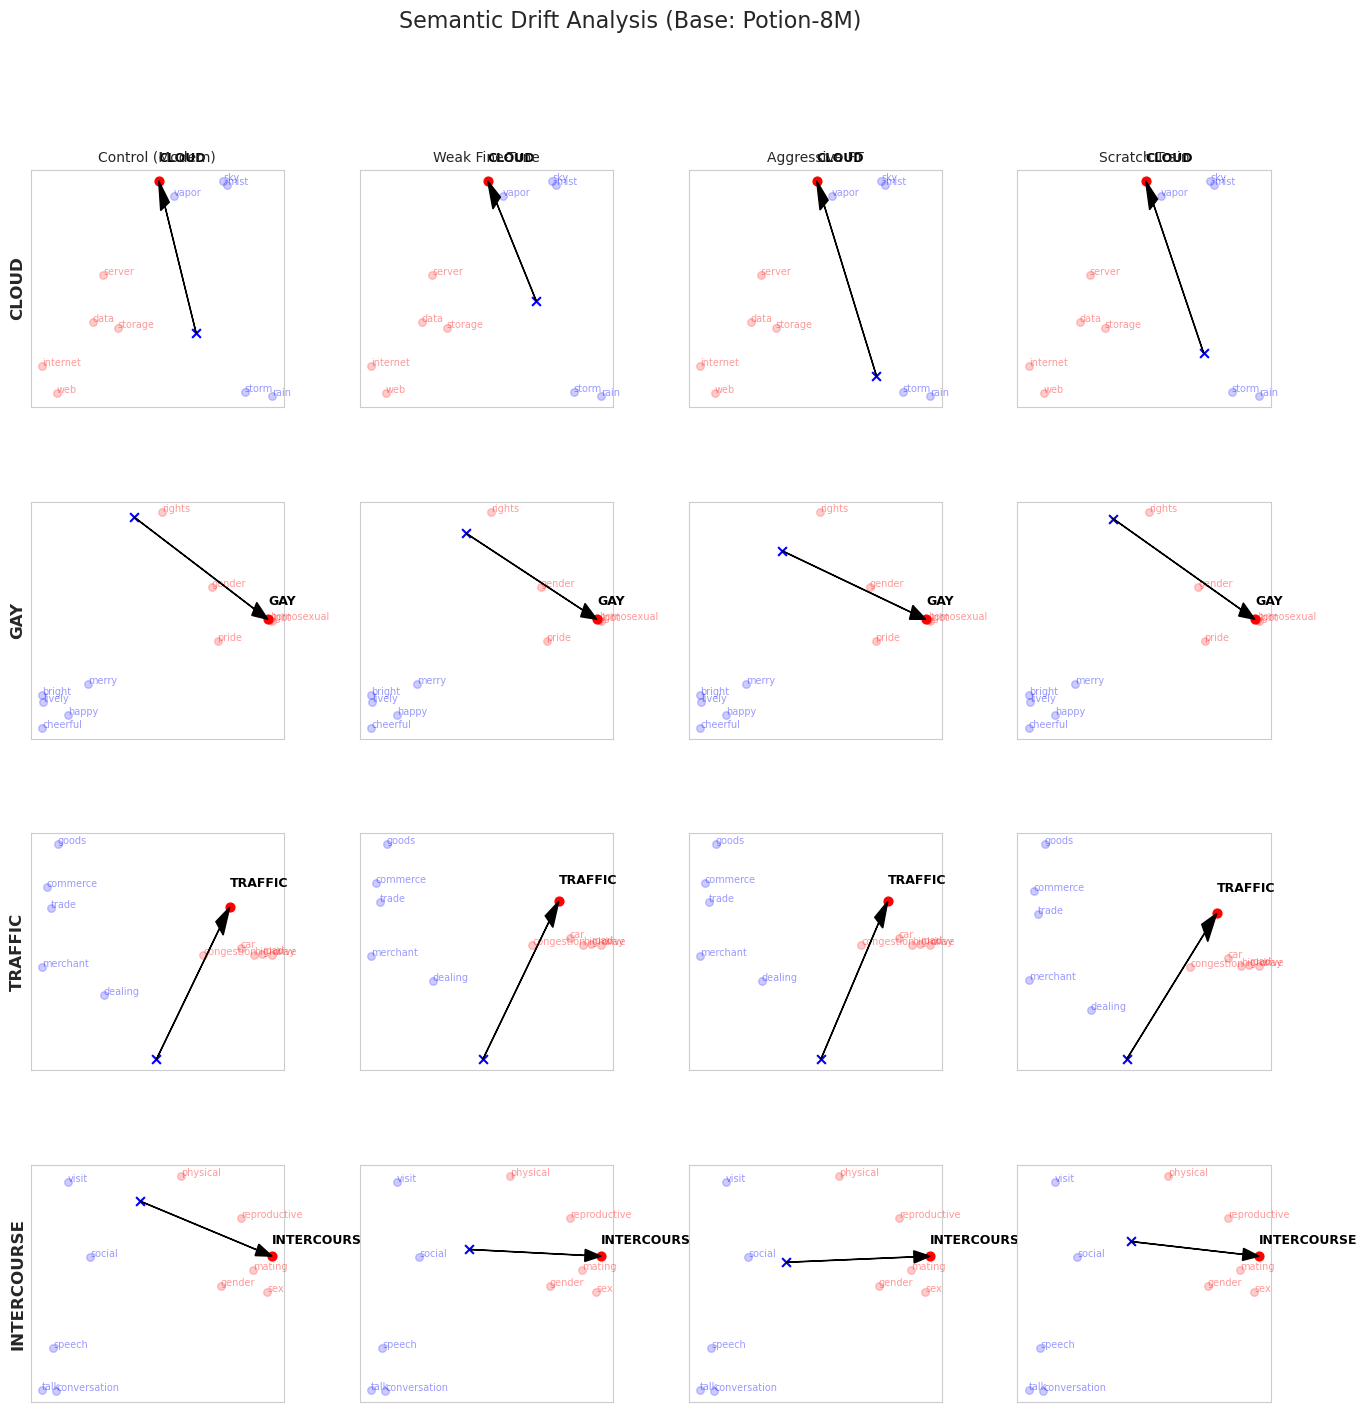

Generating dashboard for Base: MiniLM-L6...


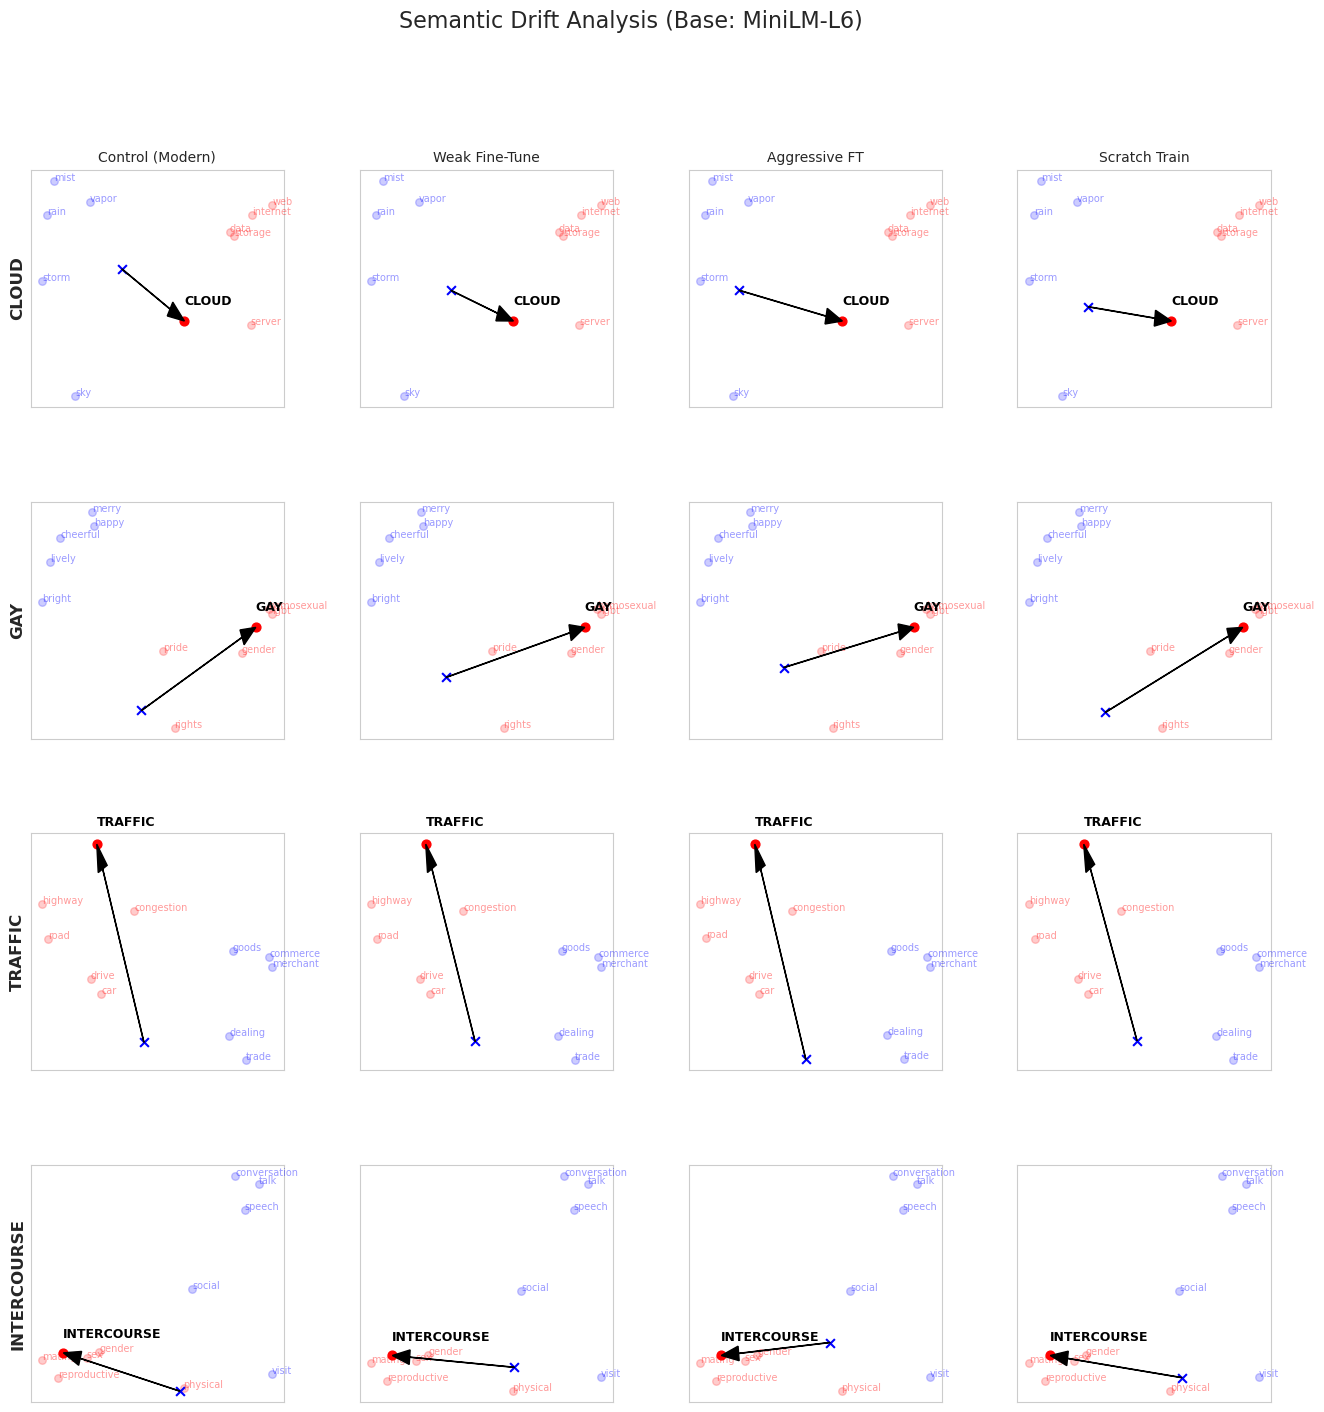

In [123]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
from model2vec import StaticModel

# --- 1. CONFIGURATION ---

# Define the models
MODEL_PATHS = {
    "BASE_1": "minishlab/potion-base-8m",         # Modern Base 1
    "BASE_2": "models/all-MiniLM-L6-v2_static",           # Modern Base 2
    
    "VARIANTS": {
        "Control (Modern)": "models/all-MiniLM-L6-v2_static",         # Self-comparison (No drift expected)
        "Weak Fine-Tune":   "models/pg19_static_final",       # Your first attempt
        "Aggressive FT":    "models/pg19_aggressive_static_final",  # The one we just made
        "Scratch Train":    "models/pg19_scratch_static_final" # The 'ab initio' model
    }
}

# Words to analyze and their changing contexts
WORD_SPECS = {
    "cloud": {
        "old": ["sky", "rain", "storm", "mist", "vapor"],
        "new": ["server", "data", "internet", "web", "storage"]
    },
    "gay": {
        "old": ["happy", "bright", "merry", "cheerful", "lively"],
        "new": ["homosexual", "lgbt", "rights", "gender", "pride"]
    },
    "traffic": {
        "old": ["trade", "commerce", "goods", "merchant", "dealing"],
        "new": ["car", "road", "highway", "congestion", "drive"]
    },
    "intercourse": {
        "old": ["conversation", "social", "speech", "talk", "visit"],
        "new": ["sex", "physical", "reproductive", "mating", "gender"]
    }
}

# Strict Anchors for Procrustes Alignment
STABLE_ANCHORS = [
    "sun", "moon", "water", "river", "mountain", "stone", "night", "day",
    "summer", "winter", "north", "south", "east", "west", "hand", "foot",
    "head", "mother", "father", "son", "daughter", "man", "woman", "life",
    "death", "eat", "drink", "walk", "speak", "the", "and", "of", "to"
]

# --- 2. HELPER FUNCTIONS ---

def get_aligned_pca(mod_base, mod_variant, anchors, all_words):
    """
    1. Aligns Variant -> Base using Strict Anchors.
    2. Fits PCA on Base (Modern Map).
    3. Returns projection function and rotation matrix.
    """
    # Align
    valid_anchors = [w for w in anchors 
                     if w in mod_base.tokenizer.get_vocab() 
                     and w in mod_variant.tokenizer.get_vocab()]
    
    vecs_base = mod_base.encode(valid_anchors)
    vecs_var = mod_variant.encode(valid_anchors)
    
    # Calculate Rotation R
    R, _ = orthogonal_procrustes(vecs_var, vecs_base)
    
    # Fit PCA on Base Contexts (Defining the Map)
    base_vectors = mod_base.encode(all_words)
    pca = PCA(n_components=2)
    pca.fit(base_vectors)
    
    return pca, R

def plot_subplot(ax, mod_base, mod_variant, word, spec, title):
    """Draws a single semantic drift plot on a given matplotlib axis."""
    
    # Prepare Data
    old_ctx = spec["old"]
    new_ctx = spec["new"]
    all_plot_words = old_ctx + new_ctx + STABLE_ANCHORS[:5] + [word]
    
    # Get Alignment & PCA
    try:
        pca, R = get_aligned_pca(mod_base, mod_variant, STABLE_ANCHORS, all_plot_words)
    except Exception as e:
        ax.text(0.5, 0.5, "Model/Vocab Error", ha='center')
        return

    # Helper for points
    def get_pt(model, w, rot=None):
        v = model.encode([w])[0]
        if rot is not None: v = v @ rot
        return pca.transform([v])[0]

    # 1. Plot Contexts (Base Model = Background Map)
    for w in old_ctx:
        p = get_pt(mod_base, w)
        ax.scatter(p[0], p[1], c='blue', alpha=0.2, s=30)
        ax.text(p[0], p[1], w, color='blue', alpha=0.4, fontsize=7)
        
    for w in new_ctx:
        p = get_pt(mod_base, w)
        ax.scatter(p[0], p[1], c='red', alpha=0.2, s=30)
        ax.text(p[0], p[1], w, color='red', alpha=0.4, fontsize=7)

    # 2. Plot Drift Arrow
    try:
        p_start = get_pt(mod_variant, word, rot=R) # 1900
        p_end = get_pt(mod_base, word)             # 2024
        
        # Draw Arrow
        ax.arrow(p_start[0], p_start[1], 
                 p_end[0]-p_start[0], p_end[1]-p_start[1], 
                 head_width=0.05, color='black', length_includes_head=True, zorder=5)
        
        # Markers
        ax.scatter([p_start[0]], [p_start[1]], c='blue', marker='x', s=40) # Start
        ax.scatter([p_end[0]], [p_end[1]], c='red', marker='o', s=40)     # End
        
        # Label only the target word to reduce clutter
        ax.text(p_end[0], p_end[1]+0.05, word.upper(), color='black', fontsize=9, fontweight='bold')
        
    except KeyError:
        ax.text(0, 0, "Word not in Vocab", ha='center')

    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# --- 3. MAIN EXECUTION ---

def generate_dashboard(base_name, base_path):
    print(f"Generating dashboard for Base: {base_name}...")
    try:
        mod_base = StaticModel.from_pretrained(base_path)
    except:
        print(f"Could not load {base_path}. Skipping.")
        return

    # Create 4x4 Grid
    # Rows: Words, Cols: Variants
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    words = list(WORD_SPECS.keys())
    variants = list(MODEL_PATHS["VARIANTS"].keys())
    
    for row_idx, word in enumerate(words):
        for col_idx, var_name in enumerate(variants):
            ax = axes[row_idx, col_idx]
            var_path = MODEL_PATHS["VARIANTS"][var_name]
            
            # Load Variant (Lazy loading to save RAM)
            try:
                mod_var = StaticModel.from_pretrained(var_path)
                
                # Title only on top row
                title = var_name if row_idx == 0 else ""
                # Word label on left column
                if col_idx == 0:
                    ax.set_ylabel(word.upper(), fontsize=12, fontweight='bold')
                
                plot_subplot(ax, mod_base, mod_var, word, WORD_SPECS[word], title)
                
            except Exception as e:
                ax.text(0.5, 0.5, f"Load Error\n{var_name}", ha='center')

    fig.suptitle(f"Semantic Drift Analysis (Base: {base_name})", fontsize=16)
    plt.show()

# Run for Base 1
generate_dashboard("Potion-8M", MODEL_PATHS["BASE_1"])

# Run for Base 2 (Standard MiniLM)
generate_dashboard("MiniLM-L6", MODEL_PATHS["BASE_2"])

Generating High-Res Dashboard for Standard Base...


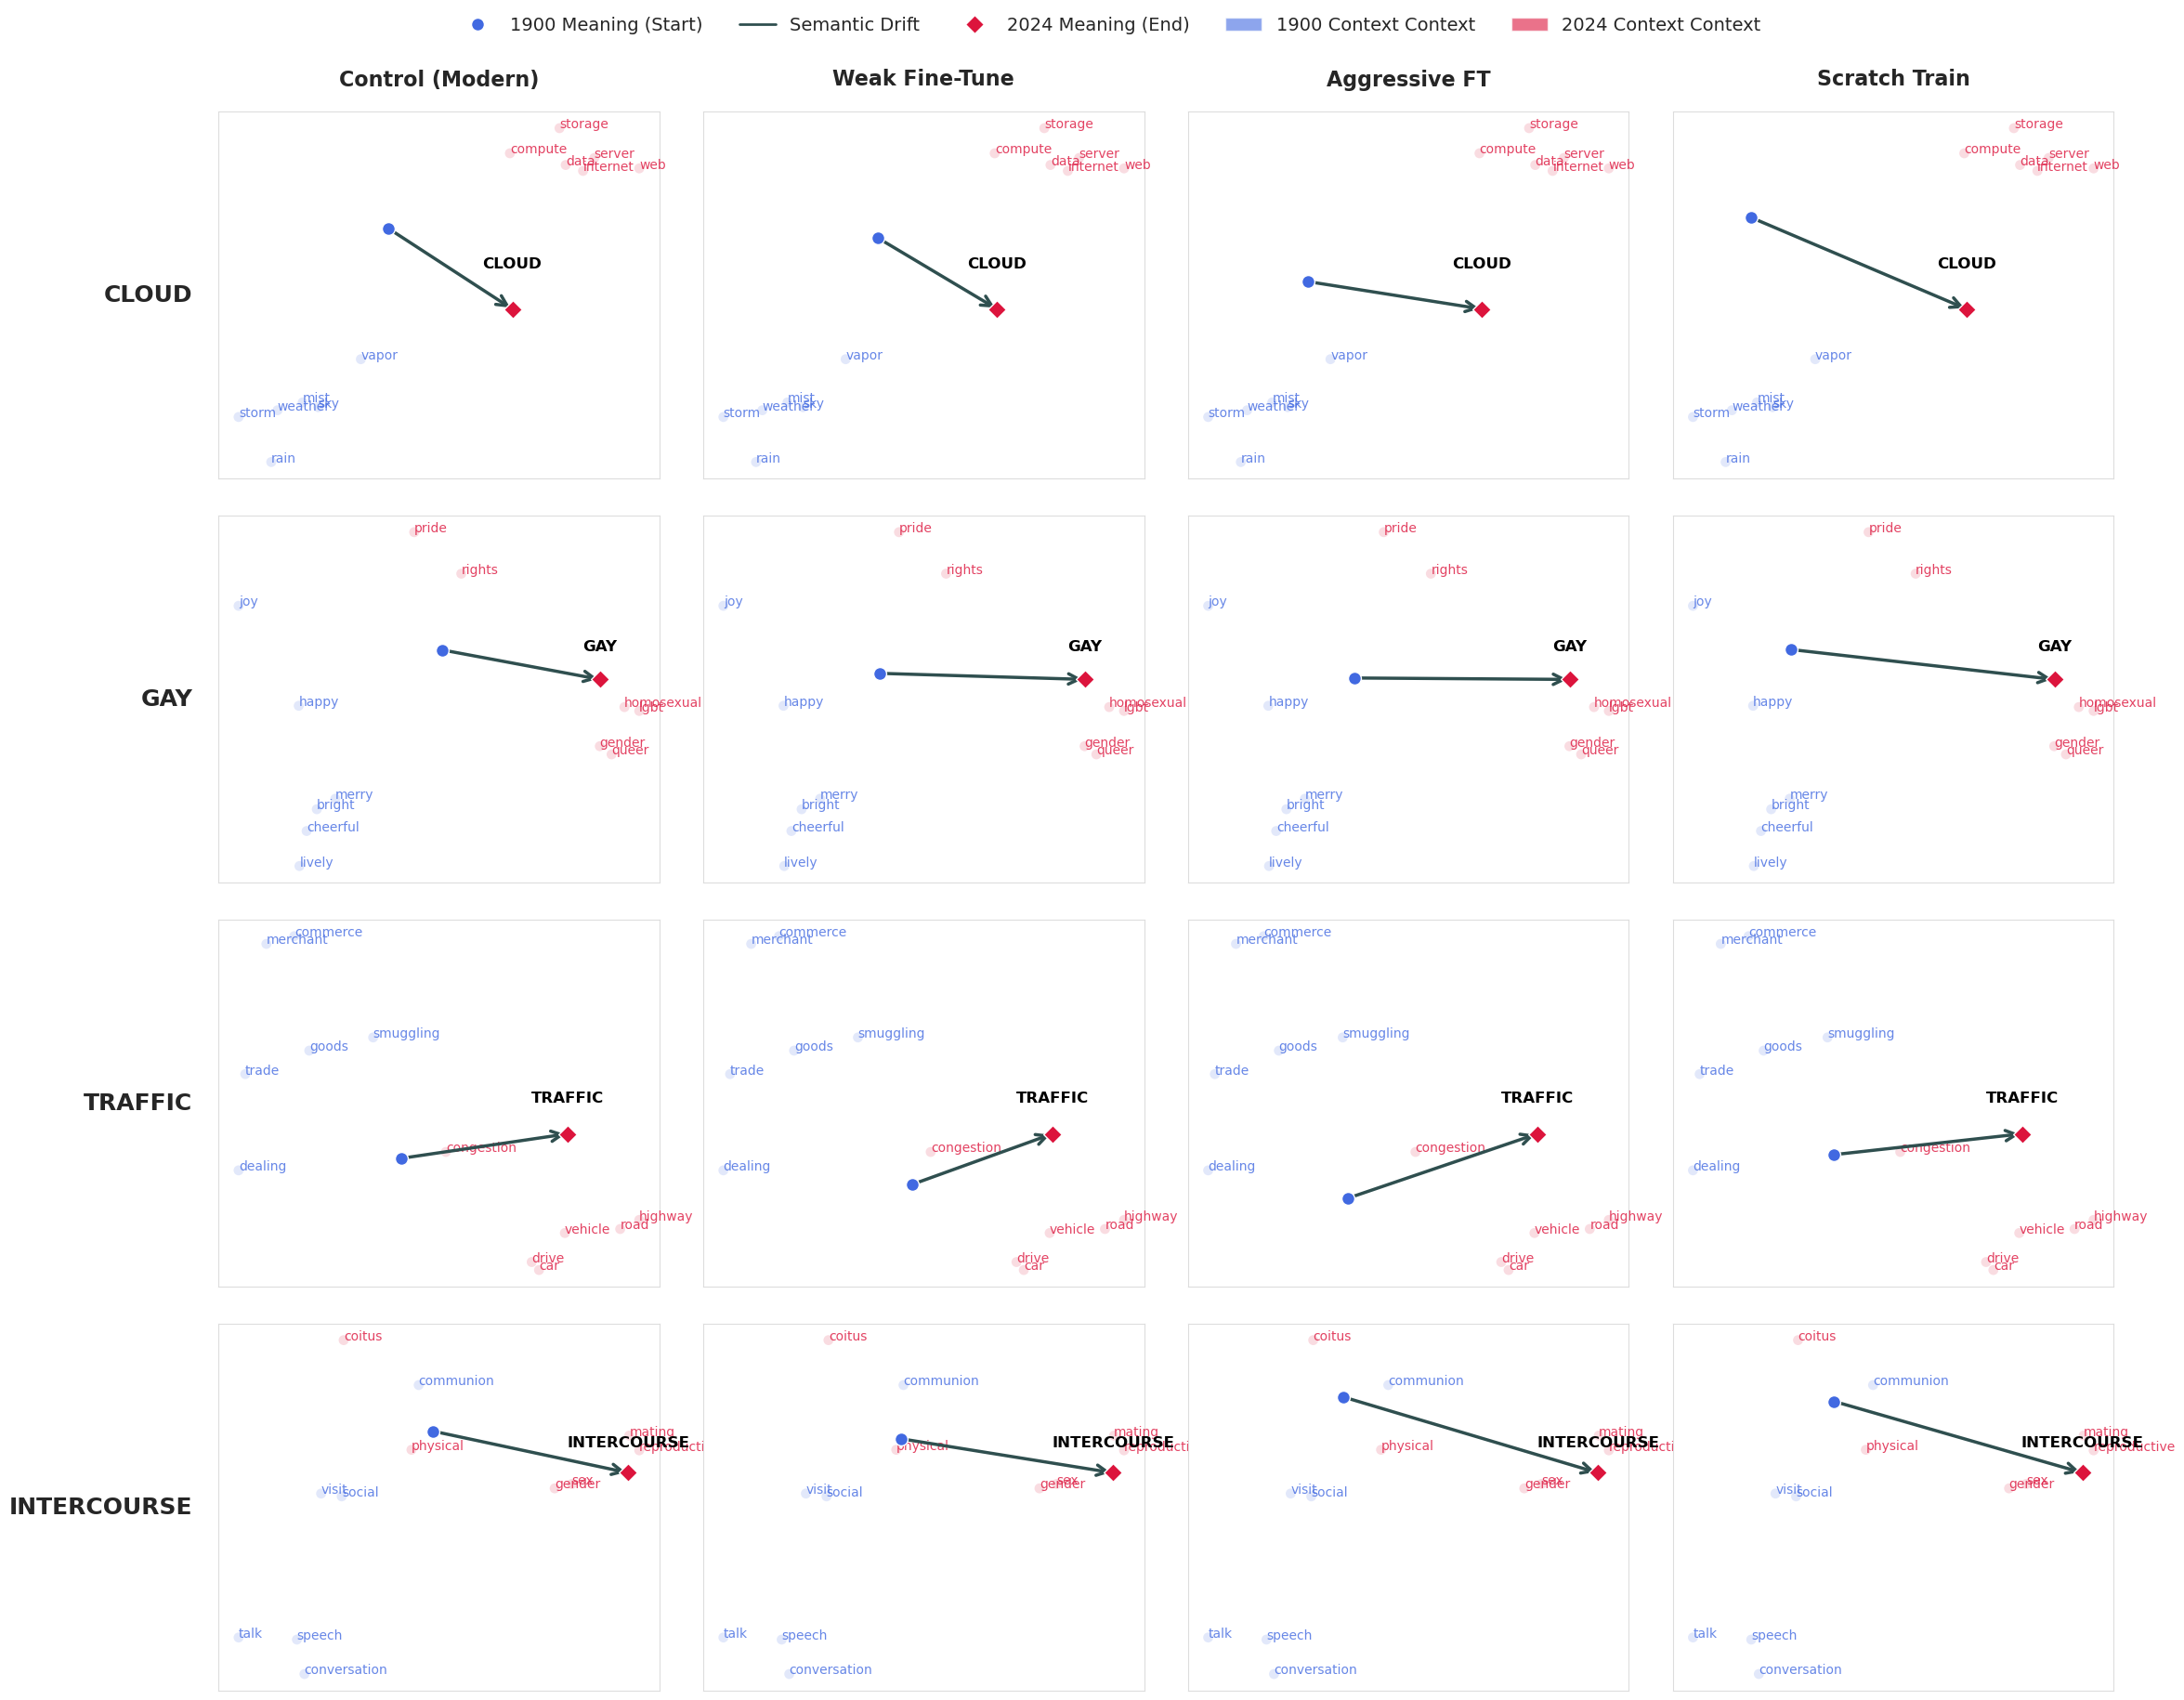

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes
from model2vec import StaticModel
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- 1. CONFIGURATION ---

MODEL_PATHS = {
    "BASE_1": "minishlab/potion-base-8m",         # Modern Base 1
    "BASE_2": "models/all-MiniLM-L6-v2_static",           # Modern Base 2
    
    "VARIANTS": {
        "Control (Modern)": "models/all-MiniLM-L6-v2_static",         # Self-comparison (No drift expected)
        "Weak Fine-Tune":   "models/pg19_static_final",       # Your first attempt
        "Aggressive FT":    "models/pg19_aggressive_static_final",  # The one we just made
        "Scratch Train":    "models/pg19_scratch_static_final" # The 'ab initio' model
    }
}

WORD_SPECS = {
    "cloud": {
        "old": ["sky", "rain", "storm", "mist", "vapor", "weather"],
        "new": ["server", "data", "internet", "web", "storage", "compute"]
    },
    "gay": {
        "old": ["happy", "bright", "merry", "cheerful", "lively", "joy"],
        "new": ["homosexual", "lgbt", "rights", "gender", "pride", "queer"]
    },
    "traffic": {
        "old": ["trade", "commerce", "goods", "merchant", "dealing", "smuggling"],
        "new": ["car", "road", "highway", "congestion", "drive", "vehicle"]
    },
    "intercourse": {
        "old": ["conversation", "social", "speech", "talk", "visit", "communion"],
        "new": ["sex", "physical", "reproductive", "mating", "gender", "coitus"]
    }
}

# STABLE_ANCHORS = [
#     "sun", "moon", "water", "river", "mountain", "stone", "night", "day",
#     "summer", "winter", "north", "south", "east", "west", "hand", "foot",
#     "head", "mother", "father", "son", "daughter", "man", "woman", "life"
# ]
STABLE_ANCHORS = [
    # Feelings
    "love", "hate", "joy", "fear", "anger", "sadness", "pain", "pleasure", "friend", "enemy",
    "happy", "sad", "good", "bad", "brave", "strong", "weak", "kind",
    # Attributes
    "big", "small", "long", "short", "hot", "cold", "old", "new", "fast", "slow",
    "light", "dark", "hard", "soft", "heavy", "thin",
    # Basic Objects
    "house", "chair", "table", "flower", "cloth", "horse", "dog", "cat", "book", "bird",
    # Physical World
    "sun", "moon", "water", "fire", "river", "mountain", "tree", "stone", "gold", "silver",
    "night", "day", "summer", "winter", "north", "south", "east", "west",
    # Basic Human
    "hand", "foot", "head", "eye", "mother", "father", "son", "daughter", "man", "woman",
    "life", "death", "sleep", "eat", "drink", "walk", "run", "speak", "write", "see",
    # Abstract/Grammar (High Frequency)
    "the", "and", "of", "to", "in", "is", "that", "with", "for", "as", "one", "two", "three"
]
# --- 2. PLOTTING ENGINE ---

def get_aligned_pca(mod_base, mod_variant, anchors, all_words):
    # Align Variant -> Base
    valid_anchors = [w for w in anchors if w in mod_base.tokenizer.get_vocab() and w in mod_variant.tokenizer.get_vocab()]
    vecs_base = mod_base.encode(valid_anchors)
    vecs_var = mod_variant.encode(valid_anchors)
    
    R, _ = orthogonal_procrustes(vecs_var, vecs_base)
    
    # Fit PCA on Base Contexts
    base_vectors = mod_base.encode(all_words)
    pca = PCA(n_components=2)
    pca.fit(base_vectors)
    
    return pca, R

def plot_subplot(ax, mod_base, mod_variant, word, spec):
    # Colors
    c_old = '#4169E1' # Royal Blue
    c_new = '#DC143C' # Crimson Red
    c_arr = '#2F4F4F' # Dark Slate Gray
    
    old_ctx = spec["old"]
    new_ctx = spec["new"]
    all_plot_words = old_ctx + new_ctx + STABLE_ANCHORS[:5] + [word]
    
    try:
        pca, R = get_aligned_pca(mod_base, mod_variant, STABLE_ANCHORS, all_plot_words)
    except:
        ax.text(0.5, 0.5, "Alignment Error", ha='center', fontsize=12, color='red')
        return

    def get_pt(model, w, rot=None):
        v = model.encode([w])[0]
        if rot is not None: v = v @ rot
        return pca.transform([v])[0]

    # 1. Plot Context Background (Faint)
    for w in old_ctx:
        p = get_pt(mod_base, w)
        ax.scatter(p[0], p[1], c=c_old, alpha=0.15, s=60, edgecolors='none')
        ax.text(p[0], p[1], w, color=c_old, alpha=0.95, fontsize=10)
        
    for w in new_ctx:
        p = get_pt(mod_base, w)
        ax.scatter(p[0], p[1], c=c_new, alpha=0.15, s=60, edgecolors='none')
        ax.text(p[0], p[1], w, color=c_new, alpha=0.95, fontsize=10)

    # 2. Plot The Drift Arrow
    try:
        p_start = get_pt(mod_variant, word, rot=R) # 1900
        p_end = get_pt(mod_base, word)             # 2024
        
        # Draw Arrow
        ax.annotate("", xy=p_end, xytext=p_start,
                    arrowprops=dict(arrowstyle="->", color=c_arr, lw=2.5, mutation_scale=20))
        
        # Draw Markers
        ax.scatter(p_start[0], p_start[1], c=c_old, marker='o', s=100, label='1900', edgecolors='white', zorder=10)
        ax.scatter(p_end[0], p_end[1], c=c_new, marker='D', s=100, label='2024', edgecolors='white', zorder=10)
        
        # Label Target
        ax.text(p_end[0], p_end[1]+0.08, word.upper(), color='black', fontsize=12, fontweight='bold', ha='center')
        
    except KeyError:
        ax.text(0.5, 0.5, "Missing Word", ha='center')

    # Cleanup Axis
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')

def generate_dashboard(base_name, base_path):
    print(f"Generating High-Res Dashboard for {base_name}...")
    try:
        mod_base = StaticModel.from_pretrained(base_path)
    except:
        print("Base model not found.")
        return

    # HUGE FIGURE SIZE for readability
    fig, axes = plt.subplots(4, 4, figsize=(24, 20), facecolor='white')
    
    # Add Legend Manually at the top
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#4169E1', label='1900 Meaning (Start)', markersize=10),
        Line2D([0], [0], color='#2F4F4F', lw=2, label='Semantic Drift'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#DC143C', label='2024 Meaning (End)', markersize=10),
        Patch(facecolor='#4169E1', alpha=0.6, label='1900 Context Context'),
        Patch(facecolor='#DC143C', alpha=0.6, label='2024 Context Context'),
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=5, fontsize=14, frameon=False, bbox_to_anchor=(0.5, 0.96))

    words = list(WORD_SPECS.keys())
    variants = list(MODEL_PATHS["VARIANTS"].keys())
    
    for row, word in enumerate(words):
        for col, var_name in enumerate(variants):
            ax = axes[row, col]
            
            # Row Labels (Words)
            if col == 0:
                ax.set_ylabel(word.upper(), fontsize=18, fontweight='heavy', rotation=0, ha='right', va='center', labelpad=20)
            
            # Column Labels (Models)
            if row == 0:
                ax.set_title(var_name, fontsize=16, fontweight='bold', pad=20)
            
            var_path = MODEL_PATHS["VARIANTS"][var_name]
            try:
                mod_var = StaticModel.from_pretrained(var_path)
                plot_subplot(ax, mod_base, mod_var, word, WORD_SPECS[word])
            except:
                ax.text(0.5, 0.5, "Load Error", ha='center')

    plt.subplots_adjust(top=0.90, left=0.1, right=0.95, bottom=0.05, wspace=0.1, hspace=0.1)
    plt.show()

# Run
generate_dashboard("Standard Base", MODEL_PATHS["BASE_2"])

In [ ]:
WORD_SPECS = {
    "cloud": {
        "old": ["sky", "rain", "storm", "mist", "vapor", "weather"],
        "new": ["server", "data", "internet", "web", "storage", "compute"]
    },
    "gay": {
        "old": ["happy", "bright", "merry", "cheerful", "lively", "joy"],
        "new": ["homosexual", "lgbt", "rights", "gender", "pride", "queer"]
    },
    "traffic": {
        "old": ["trade", "commerce", "goods", "merchant", "dealing", "smuggling"],
        "new": ["car", "road", "highway", "congestion", "drive", "vehicle"]
    },
    "intercourse": {
        "old": ["conversation", "social", "speech", "talk", "visit", "communion"],
        "new": ["sex", "physical", "reproductive", "mating", "gender", "coitus"]
    }
}

STABLE_ANCHORS = [
    # Feelings
    "love", "hate", "joy", "fear", "anger", "sadness", "pain", "pleasure", "friend", "enemy",
    "happy", "sad", "good", "bad", "brave", "strong", "weak", "kind",
    # Attributes
    "big", "small", "long", "short", "hot", "cold", "old", "new", "fast", "slow",
    "light", "dark", "hard", "soft", "heavy", "thin",
    # Basic Objects
    "house", "chair", "table", "flower", "cloth", "horse", "dog", "cat", "book", "bird",
    # Physical World
    "sun", "moon", "water", "fire", "river", "mountain", "tree", "stone", "gold", "silver",
    "night", "day", "summer", "winter", "north", "south", "east", "west",
    # Basic Human
    "hand", "foot", "head", "eye", "mother", "father", "son", "daughter", "man", "woman",
    "life", "death", "sleep", "eat", "drink", "walk", "run", "speak", "write", "see",
    # Grammar
    "the", "and", "of", "to", "in", "is", "that", "with", "for", "as", "one", "two", "three"
]

# --- 2. HELPER FUNCTIONS ---

def get_nearest_neighbors(model, word, top_k=3):
    """
    Finds the top_k closest words in the model's vocabulary.
    Returns a formatted string like "1. word (0.12)\n2. word..."
    """
    try:
        # 1. Get vector
        vec = model.encode([word])
        
        # 2. Get vocab
        vocab_keys = list(model.tokenizer.get_vocab().keys())
        # Filter junk (too short, subwords) to get clean English words
        vocab = [w for w in vocab_keys if len(w) > 3 and not w.startswith("##")]
        
        # 3. Calculate distances
        all_vecs = model.encode(vocab)
        dists = cdist(vec, all_vecs, metric='cosine')[0]
        
        # 4. Sort
        # We skip index 0 because it's usually the word itself (distance 0)
        sorted_indices = np.argsort(dists)
        
        neighbors = []
        count = 0
        for idx in sorted_indices:
            cand = vocab[idx]
            if cand.lower() == word.lower(): continue # Skip self
            neighbors.append(cand)
            count += 1
            if count >= top_k: break
            
        return neighbors
    except:
        return ["N/A"]

def get_aligned_pca(mod_base, mod_variant, anchors, all_words):
    # Align Variant -> Base
    valid_anchors = [w for w in anchors if w in mod_base.tokenizer.get_vocab() and w in mod_variant.tokenizer.get_vocab()]
    vecs_base = mod_base.encode(valid_anchors)
    vecs_var = mod_variant.encode(valid_anchors)
    
    R, _ = orthogonal_procrustes(vecs_var, vecs_base)
    
    # Fit PCA on Base Contexts
    base_vectors = mod_base.encode(all_words)
    pca = PCA(n_components=2)
    pca.fit(base_vectors)
    
    return pca, R

def plot_subplot(ax, mod_base, mod_variant, word, spec):
    # Colors
    c_old = '#4169E1' # Royal Blue
    c_new = '#DC143C' # Crimson Red
    c_arr = '#2F4F4F' # Dark Slate Gray
    
    old_ctx = spec["old"]
    new_ctx = spec["new"]
    all_plot_words = old_ctx + new_ctx + STABLE_ANCHORS[:5] + [word]
    
    try:
        pca, R = get_aligned_pca(mod_base, mod_variant, STABLE_ANCHORS, all_plot_words)
    except:
        ax.text(0.5, 0.5, "Alignment Error", ha='center', fontsize=12, color='red')
        return

    def get_pt(model, w, rot=None):
        v = model.encode([w])[0]
        if rot is not None: v = v @ rot
        return pca.transform([v])[0]

    # --- PLOT NEIGHBORS TEXT ---
    # 1. Get Neighbors for 1900 (Variant Model)
    neigh_old = get_nearest_neighbors(mod_variant, word, top_k=3)
    text_old = f"1900 Neighbors:\n• " + "\n• ".join(neigh_old)
    
    # 2. Get Neighbors for 2024 (Base Model)
    neigh_new = get_nearest_neighbors(mod_base, word, top_k=3)
    text_new = f"2024 Neighbors:\n• " + "\n• ".join(neigh_new)
    
    # 3. Add Text Boxes (Top Left and Top Right)
    # Transform=ax.transAxes allows us to position relative to the box (0,0 to 1,1)
    ax.text(0.02, 0.98, text_old, transform=ax.transAxes, fontsize=9, 
            verticalalignment='top', color=c_old, fontweight='bold', 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
            
    ax.text(0.98, 0.98, text_new, transform=ax.transAxes, fontsize=9, 
            verticalalignment='top', horizontalalignment='right', 
            color=c_new, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # --- PLOT SCATTER & ARROWS ---

    # 1. Plot Context Background (Faint)
    for w in old_ctx:
        p = get_pt(mod_base, w)
        ax.scatter(p[0], p[1], c=c_old, alpha=0.15, s=60, edgecolors='none')
        ax.text(p[0], p[1], w, color=c_old, alpha=0.95, fontsize=10)
        
    for w in new_ctx:
        p = get_pt(mod_base, w)
        ax.scatter(p[0], p[1], c=c_new, alpha=0.15, s=60, edgecolors='none')
        ax.text(p[0], p[1], w, color=c_new, alpha=0.95, fontsize=10)

    # 2. Plot The Drift Arrow
    try:
        p_start = get_pt(mod_variant, word, rot=R) # 1900
        p_end = get_pt(mod_base, word)             # 2024
        
        # Draw Arrow
        ax.annotate("", xy=p_end, xytext=p_start,
                    arrowprops=dict(arrowstyle="->", color=c_arr, lw=2.5, mutation_scale=20))
        
        # Draw Markers
        ax.scatter(p_start[0], p_start[1], c=c_old, marker='o', s=100, label='1900', edgecolors='white', zorder=10)
        ax.scatter(p_end[0], p_end[1], c=c_new, marker='D', s=100, label='2024', edgecolors='white', zorder=10)
        
        # Label Target
        ax.text(p_end[0], p_end[1]+0.08, word.upper(), color='black', fontsize=12, fontweight='bold', ha='center')
        
    except KeyError:
        ax.text(0.5, 0.5, "Missing Word", ha='center')

    # Cleanup Axis
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')

def generate_dashboard(base_name, base_path):
    print(f"Generating High-Res Dashboard for {base_name}...")
    try:
        mod_base = StaticModel.from_pretrained(base_path)
    except:
        print("Base model not found.")
        return

    # HUGE FIGURE SIZE for readability
    fig, axes = plt.subplots(4, 4, figsize=(24, 20), facecolor='white')
    
    # Add Legend Manually at the top
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#4169E1', label='1900 Meaning (Start)', markersize=10),
        Line2D([0], [0], color='#2F4F4F', lw=2, label='Semantic Drift'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='#DC143C', label='2024 Meaning (End)', markersize=10),
        Patch(facecolor='#4169E1', alpha=0.6, label='1900 Context Context'),
        Patch(facecolor='#DC143C', alpha=0.6, label='2024 Context Context'),
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=5, fontsize=14, frameon=False, bbox_to_anchor=(0.5, 0.96))

    words = list(WORD_SPECS.keys())
    variants = list(MODEL_PATHS["VARIANTS"].keys())
    
    for row, word in enumerate(words):
        for col, var_name in enumerate(variants):
            ax = axes[row, col]
            
            # Row Labels (Words)
            if col == 0:
                ax.set_ylabel(word.upper(), fontsize=18, fontweight='heavy', rotation=0, ha='right', va='center', labelpad=20)
            
            # Column Labels (Models)
            if row == 0:
                ax.set_title(var_name, fontsize=16, fontweight='bold', pad=20)
            
            var_path = MODEL_PATHS["VARIANTS"][var_name]
            try:
                mod_var = StaticModel.from_pretrained(var_path)
                plot_subplot(ax, mod_base, mod_var, word, WORD_SPECS[word])
            except Exception as e:
                print(e)
                ax.text(0.5, 0.5, "Load Error", ha='center')

    plt.subplots_adjust(top=0.90, left=0.1, right=0.95, bottom=0.05, wspace=0.1, hspace=0.1)
    plt.show()

# Run
generate_dashboard("Standard Base", MODEL_PATHS["BASE_2"])

Generating High-Res Dashboard for Standard Base...
